In [1]:
import pandas as pd 
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt 

### Problem 1

In [2]:
X_1 = np.array([300,420,540,660]).reshape(4,1)
X_1 = np.concat((np.array([1,1,1,1]).reshape(4,1), X_1), axis=1)
y_1 = np.array([0.79,0.77,0.76,0.73]).reshape(4,1)

In [3]:
np.linalg.inv(X_1.T.dot(X_1)).dot(X_1.T.dot(y_1))

array([[ 8.38500000e-01],
       [-1.58333333e-04]])

### Problem 2

In [4]:
X_2 = (np.arange(6)+1).reshape(-1,1)
y_2 = np.array([31.2,32.4,33.4,34.0,34.6,35.0]).reshape(-1,1)

In [5]:
X_2 = np.concat((np.array([1]*6).reshape(-1,1), X_2), axis=1)

In [6]:
np.linalg.inv(X_2.T.dot(X_2)).dot(X_2.T.dot(y_2))

array([[30.81333333],
       [ 0.74857143]])

In [7]:
0.5**2 / ((X_2[:,1] - X_2[:,1].mean())**2).sum() # variance of b1

np.float64(0.014285714285714285)

In [8]:
np.linalg.inv(X_2.T.dot(X_2)) * 0.5**2 # variance of b0, b1

array([[ 0.21666667, -0.05      ],
       [-0.05      ,  0.01428571]])

In [9]:
np.sqrt(0.01428571)

np.float64(0.11952284300500889)

In [10]:
stats.t.sf(0.74857, scale=np.sqrt(0.01428571), df=4) # standard error of b1

np.float64(0.0016579281800691583)

In [11]:
np.linalg.inv(X_2.T.dot(X_2)) * 0.05**2

array([[ 0.00216667, -0.0005    ],
       [-0.0005    ,  0.00014286]])

### Problem 3

In [12]:
df_3 = pd.DataFrame({
    'x': np.arange(4)+1,
    'y': [6,6,10,30]
})

df_3['xx'] = df_3['x']**2
df_3

,x,y,xx
0,1,6,1
1,2,6,4
2,3,10,9
3,4,30,16


In [13]:
X_3 = df_3[['xx']].to_numpy()
y_3 = df_3[['y']].to_numpy()
X_3, y_3

(array([[ 1],
        [ 4],
        [ 9],
        [16]]),
 array([[ 6],
        [ 6],
        [10],
        [30]]))

In [14]:
np.linalg.inv(X_3.T.dot(X_3)).dot(X_3.T.dot(y_3))

array([[1.69491525]])

In [15]:
1.695 * 5**2

42.375

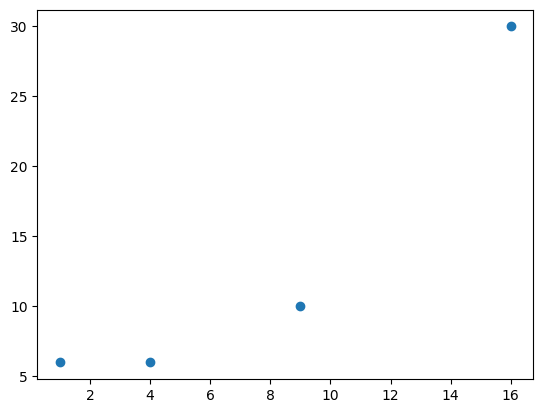

In [16]:
plt.scatter(X_3, y_3)

### Problem 4

In [17]:
X_4 = np.array([10,20,30,40,50,60]).reshape(-1,1)
X_4_0 = np.concat((np.array([1]*6).reshape(-1,1), X_4),axis=1)
y_4 = np.array([2.7,3.6,5.2,6.1,6.0,4.9]).reshape(-1,1)

In [18]:
b0_4, b_4 = np.linalg.inv(X_4_0.T.dot(X_4_0)).dot(X_4_0.T.dot(y_4))

In [19]:
x_bar_4 = X_4.mean()
y_bar_4 = y_4.mean()
y_hat_4 = b0_4 + b_4*X_4

In [20]:
s2_4 = ((y_4 - y_hat_4)**2).sum() / (6-2) # mean square for estimate variance

In [21]:
s2_4

np.float64(0.9808571428571423)

In [22]:
np.sqrt(np.linalg.inv(X_4_0.T.dot(X_4_0)) * s2_4)

C:\Users\PeiguangHu\AppData\Local\Temp\ipykernel_25512\1620923109.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(np.linalg.inv(X_4_0.T.dot(X_4_0)) * s2_4)


array([[0.92199576,        nan],
       [       nan, 0.02367467]])

In [23]:
b0_4, b_4

(array([2.84]), array([0.05457143]))

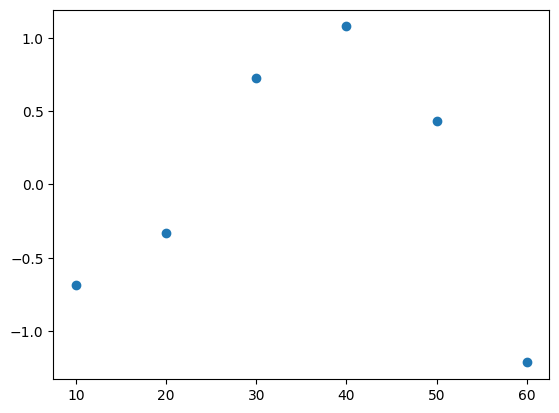

In [24]:
# check residual
plt.scatter(X_4, y_4 - y_hat_4)

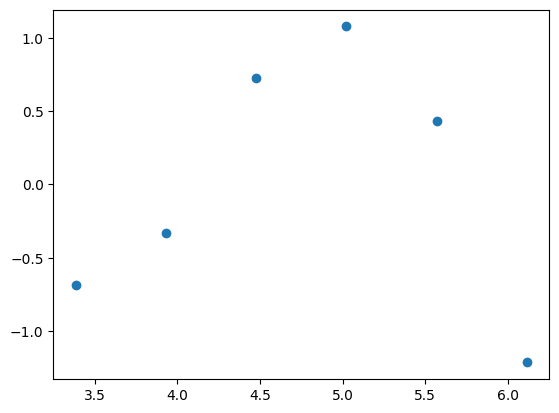

In [25]:
# check residual
plt.scatter(y_hat_4, y_4 - y_hat_4)

In [26]:
# not random errors. need to add another square term
X_4_2 = np.concat((X_4_0, X_4**2), axis=1)
X_4_2

array([[   1,   10,  100],
       [   1,   20,  400],
       [   1,   30,  900],
       [   1,   40, 1600],
       [   1,   50, 2500],
       [   1,   60, 3600]])

In [27]:
b0_4_2, b1_4_2, b2_4_2 = np.linalg.inv(X_4_2.T.dot(X_4_2)).dot(X_4_2.T.dot(y_4))

In [28]:
b0_4_2, b1_4_2, b2_4_2

(array([0.04]), array([0.26457143]), array([-0.003]))

In [29]:
y_hat_4_2 = b0_4_2 + b1_4_2*X_4 + b2_4_2*X_4**2

In [30]:
s2_4_2 = ((y_4 - (b0_4_2 + b1_4_2*X_4 + b2_4_2*X_4**2))**2).sum()
s2_4_2

np.float64(0.5634285714285713)

In [31]:
np.sqrt(np.linalg.inv(X_4_2.T.dot(X_4_2)) * s2_4_2)

C:\Users\PeiguangHu\AppData\Local\Temp\ipykernel_25512\2999264779.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(np.linalg.inv(X_4_2.T.dot(X_4_2)) * s2_4_2)


array([[1.34274772e+00,            nan, 3.75309396e-02],
       [           nan, 8.78462246e-02,            nan],
       [3.75309396e-02,            nan, 1.22848837e-03]])

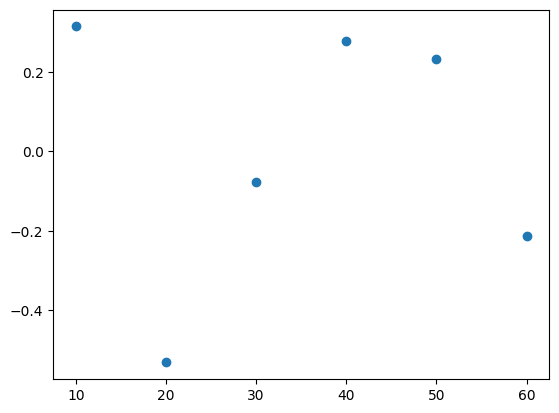

In [32]:
# check residual
plt.scatter(X_4, y_4 - y_hat_4_2)

### Problem 5

In [33]:
X_5 = np.array([1,1,2,2,3,3,4,4,]).reshape(-1,1)
y_5 = np.array([15,21,36,32,38,49,33,30])

In [34]:
X_5_2 = np.concat((X_5, X_5**2), axis=1) #np.array([1]*8).reshape(-1,1), 

In [35]:
b1_5, b2_5 = np.linalg.inv(X_5_2.T.dot(X_5_2)).dot(X_5_2.T.dot(y_5))

In [36]:
b1_5, b2_5

(np.float64(26.282258064516146), np.float64(-4.459677419354838))

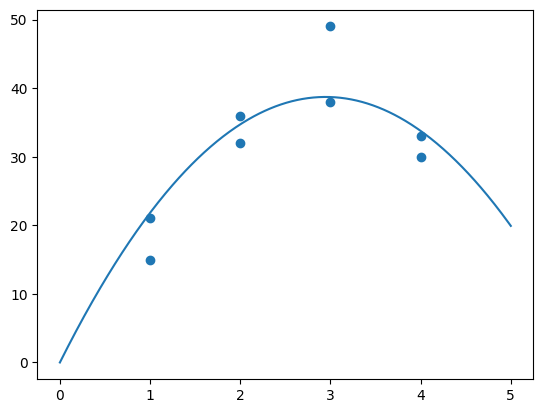

In [37]:
plt.scatter(X_5, y_5)
plt.plot(np.linspace(0,5,501), b1_5*np.linspace(0,5,501)+b2_5*np.linspace(0,5,501)**2)

In [38]:
# sum of squares (df 4) by replicates and sum of squares by residuals (6)
SE2_5 = 0
SR2_5 = 0
for i in range(4):
    SE2_5 += y_5[i*2:(i+1)*2].var(ddof=1)
    SR2_5 += ((y_5[i*2:(i+1)*2] - b1_5*X_5[i*2:(i+1)*2]-b2_5*X_5[i*2:(i+1)*2]**2)**2).sum() 
SL2_5 = SR2_5 - SE2_5 # df 2
SE2_5, SR2_5, SL2_5


(np.float64(91.0),
 np.float64(355.03225806451604),
 np.float64(264.03225806451604))

In [39]:
# standard error by replicates
se2_5 = SE2_5 / 4
sl2_5 = SL2_5 / 2
se2_5, sl2_5, sl2_5/se2_5

(np.float64(22.75),
 np.float64(132.01612903225802),
 np.float64(5.802906770648704))

In [40]:
stats.f.sf(sl2_5/se2_5, dfn=2, dfd=4)

np.float64(0.06569724461660996)

### Problem 14

In [41]:
# assume no error of x
df_14 = pd.DataFrame({
    'x0': [1]*5,
    'x1': np.linspace(12,16,5),
    'y':[404,412,413,415,422]
})

df_14

,x0,x1,y
0,1,12.0,404
1,1,13.0,412
2,1,14.0,413
3,1,15.0,415
4,1,16.0,422


In [42]:
X_14 = df_14[['x0', 'x1']].to_numpy()
y_14 = df_14[['y']].to_numpy()

In [43]:
bs_14 = np.linalg.inv(X_14.T.dot(X_14)).dot(X_14.T.dot(y_14))
bs_14

array([[358.6],
       [  3.9]])

In [44]:
df_14['y_hat'] = X_14.dot(bs_14)
df_14

,x0,x1,y,y_hat
0,1,12.0,404,405.4
1,1,13.0,412,409.3
2,1,14.0,413,413.2
3,1,15.0,415,417.1
4,1,16.0,422,421.0


In [45]:
SSR_14 =((df_14['y'] - df_14['y_hat'])**2).sum() # sum of squares of residuals with (5-2)=3 degrees of freedom
MSR_14 = SSR_14/3
SER_14 = np.sqrt(MSR_14)
SSR_14, MSR_14, SER_14

(np.float64(14.700000000000237),
 np.float64(4.900000000000079),
 np.float64(2.2135943621178833))

In [46]:
# y at x=10
y10_14 = np.array([[1,10]]).dot(bs_14)
y10_14

array([[397.6]])

In [47]:
# variance of y at x=10 
var10_14 = (1/5 + (10-df_14['x1'].mean())**2/((df_14['x1']-df_14['x1'].mean())**2).sum()) * MSR_14 # degree of freedom 3
se10_14 = np.sqrt(var10_14)
var10_14, se10_14

(np.float64(8.820000000000142), np.float64(2.9698484809835235))

In [48]:
y10_14 - stats.t.isf(0.025, scale=se10_14, df=3), y10_14 + stats.t.isf(0.025, scale=se10_14, df=3), 

(array([[388.14861667]]), array([[407.05138333]]))

### Problem 15

In [49]:
df_15 = pd.DataFrame({
    'x0': [1]*8,
    'x1': [(-1)**(i//1+1) for i in range(8)],
    'x2': [(-1)**(i//2+1) for i in range(8)],
    'y': [6,14,13,7,4,14,10,8]
})
df_15

,x0,x1,x2,y
0,1,-1,-1,6
1,1,1,-1,14
2,1,-1,1,13
3,1,1,1,7
4,1,-1,-1,4
5,1,1,-1,14
6,1,-1,1,10
7,1,1,1,8


In [50]:
X_15a = df_15[['x0', 'x1', 'x2']]
y_15 = df_15[['y']]
bs_15a = np.linalg.inv(X_15a.T.dot(X_15a)).dot(X_15a.T.dot(y_15))
bs_15a

array([[9.5 ],
       [1.25],
       [0.  ]])

In [51]:
df_15['y_hat_a'] = X_15a.dot(bs_15a)
df_15

,x0,x1,x2,y,y_hat_a
0,1,-1,-1,6,8.25
1,1,1,-1,14,10.75
2,1,-1,1,13,8.25
3,1,1,1,7,10.75
4,1,-1,-1,4,8.25
5,1,1,-1,14,10.75
6,1,-1,1,10,8.25
7,1,1,1,8,10.75


In [52]:
SSR_15b = ((df_15['y'] - df_15['y_hat_a'])**2).sum()
MSR_15b = SSR_15b / (8-3)
MSR_15b # mean square error to estimate experimental error variance of an individual yield reading

np.float64(18.3)

In [53]:
df_15['x11'] = df_15['x1']**2
df_15['x22'] = df_15['x2']**2
df_15['x12'] = df_15['x1']*df_15['x2']
df_15

,x0,x1,x2,y,y_hat_a,x11,x22,x12
0,1,-1,-1,6,8.25,1,1,1
1,1,1,-1,14,10.75,1,1,-1
2,1,-1,1,13,8.25,1,1,-1
3,1,1,1,7,10.75,1,1,1
4,1,-1,-1,4,8.25,1,1,1
5,1,1,-1,14,10.75,1,1,-1
6,1,-1,1,10,8.25,1,1,-1
7,1,1,1,8,10.75,1,1,1


In [54]:
X_15c = df_15[['x0', 'x1', 'x2', 'x12']].to_numpy() ## beta11 and beta22 compound with mean. no way to estimate all 3
bs_15c = np.linalg.inv(X_15c.T.dot(X_15c)).dot(X_15c.T.dot(y_15))
bs_15c

array([[ 9.5 ],
       [ 1.25],
       [ 0.  ],
       [-3.25]])

In [55]:
def yates_algor(pd_serie, n):
    '''
    pd_serie: results in the correct order according to Yates algorithm
    n: number of iterations
    '''
    for i in range(n):
        # print(pd_serie)
        index_1 = pd_serie.index[::2]
        index_2 = pd_serie.index[1::2]
        serie_1 = pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        serie_2 = -pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        pd_serie = pd.concat((serie_1, serie_2)).reset_index(drop=True)

    pd_serie = pd_serie / pd_serie.shape[0] * 2
    pd_serie.iloc[0] = pd_serie.iloc[0] / 2
    return pd_serie

In [56]:
df_15['y'].mean()

np.float64(9.5)

In [57]:
df_15.groupby('x1')['y'].mean().diff(-1)

x1
-1   -2.5
 1    NaN
Name: y, dtype: float64

In [58]:
df_15.groupby('x2')['y'].mean().diff(-1), 

(x2
 -1    0.0
  1    NaN
 Name: y, dtype: float64,)

In [59]:
df_15.groupby(['x1','x2'])['y'].mean().diff(-2).diff(-1)/2, 

(x1  x2
 -1  -1   -6.5
      1    NaN
  1  -1    NaN
      1    NaN
 Name: y, dtype: float64,)

### Problem 16

In [60]:
df_16 = pd.DataFrame({
    'order': np.arange(6)+1,
    'x': [51,38,40,67,21,13],
    'y': [61,52,58,57,41,21],

})
df_16

,order,x,y
0,1,51,61
1,2,38,52
2,3,40,58
3,4,67,57
4,5,21,41
5,6,13,21


<Axes: xlabel='x', ylabel='y'>

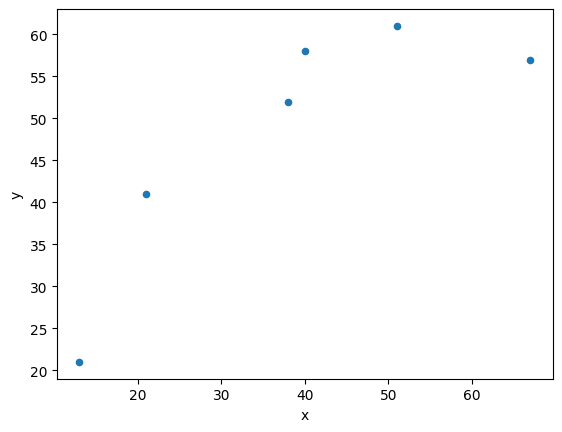

In [61]:
df_16.plot.scatter(x='x', y='y') # first, does not seem linear, second, if fitting linear, the line does not pass through (0,0)

In [62]:
X_16a = df_16[['x']].to_numpy()
y_16 = df_16[['y']].to_numpy()
b_16a = np.linalg.inv(X_16a.T.dot(X_16a)).dot(X_16a.T.dot(y_16))
b_16a

array([[1.15040953]])

In [63]:
16 / ((df_16['x'])**2).sum() # variance of b_16a

np.float64(0.0014892032762472078)

In [64]:
np.linalg.inv(X_16a.T.dot(X_16a)) * 16

array([[0.0014892]])

In [65]:
b_16a, b_16a - 0.0015*stats.norm.isf(0.05), b_16a + stats.norm.isf(0.05, scale=0.0015)

(array([[1.15040953]]), array([[1.14794225]]), array([[1.15287681]]))

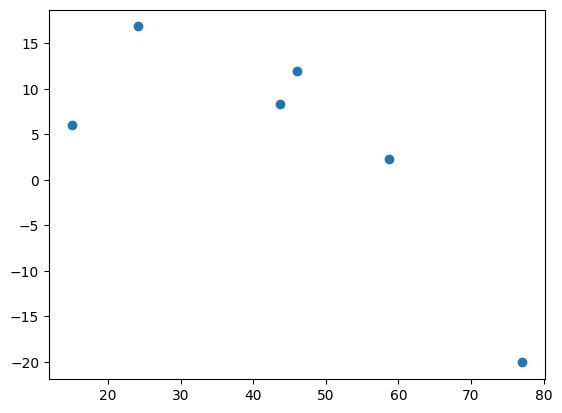

In [66]:
#16d plot the y_hat vs residuals. clear trends. take into account of test order
plt.scatter(X_16a.dot(b_16a), df_16[['y']].to_numpy() - X_16a.dot(b_16a))

In [67]:
((df_16[['y']].to_numpy() - X_16a.dot(b_16a))**2).sum() / 16

np.float64(58.808637379002235)

In [68]:
df_16['x^2'] = df_16['x']**2
df_16

,order,x,y,x^2
0,1,51,61,2601
1,2,38,52,1444
2,3,40,58,1600
3,4,67,57,4489
4,5,21,41,441
5,6,13,21,169


In [69]:
X_16d = df_16[['x','x^2']]
bs_16d = np.linalg.inv(X_16d.T.dot(X_16d)).dot(X_16d.T.dot(y_16))
var_bs_16d = np.linalg.inv(X_16d.T.dot(X_16d)) * 16
bs_16d, var_bs_16d, np.sqrt(var_bs_16d)

C:\Users\PeiguangHu\AppData\Local\Temp\ipykernel_25512\385904617.py:4: RuntimeWarning: invalid value encountered in sqrt
  bs_16d, var_bs_16d, np.sqrt(var_bs_16d)


(array([[ 2.20920038],
        [-0.02017875]]),
 array([[ 2.14711440e-02, -3.80821740e-04],
        [-3.80821740e-04,  7.25781344e-06]]),
 array([[0.14653035,        nan],
        [       nan, 0.00269403]]))

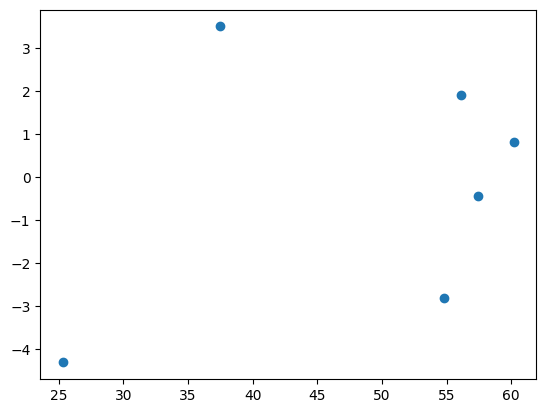

In [70]:
plt.scatter(X_16d.dot(bs_16d), df_16[['y']].to_numpy() - X_16d.dot(bs_16d))

In [71]:
((df_16[['y']].to_numpy() - X_16d.dot(bs_16d))**2).sum() / 16

0    2.706076
dtype: float64

### Problem 20

In [72]:
df_20 = pd.DataFrame({
    'test': np.arange(12)+1,
    'ratio': [10,14,10,14,8,16,12,12,12,12,12,12],
    'temp': [540,540,560,560,550,550,530,570,550,550,550,550],
    'y': [1220,1500,1430,1650,1210,1700,1200,1600,1440,1450,1350,1360],
    'residual': [14,48,41,4,31,29,-32,-29,14,24,-76,-66]
})

df_20['x1'] = (df_20['ratio'] - 12)/2
df_20['x2'] = (df_20['temp'] - 550)/10
df_20['x0'] = [1]*12

df_20

,test,ratio,temp,y,residual,x1,x2,x0
0,1,10,540,1220,14,-1.0,-1.0,1
1,2,14,540,1500,48,1.0,-1.0,1
2,3,10,560,1430,41,-1.0,1.0,1
3,4,14,560,1650,4,1.0,1.0,1
4,5,8,550,1210,31,-2.0,0.0,1
5,6,16,550,1700,29,2.0,0.0,1
6,7,12,530,1200,-32,0.0,-2.0,1
7,8,12,570,1600,-29,0.0,2.0,1
8,9,12,550,1440,14,0.0,0.0,1
9,10,12,550,1450,24,0.0,0.0,1


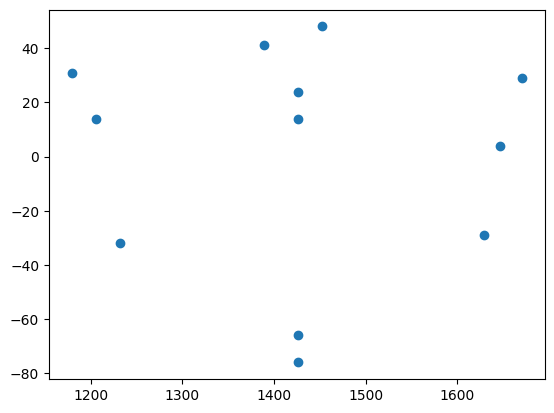

In [73]:
# check residuals
plt.scatter(df_20['y']-df_20['residual'], df_20['residual'])

In [74]:
# sum of squares of residuals with degree of freedom of (12-3)=9
SSR_20 = (df_20['residual']**2).sum()
SSR_20

np.int64(18768)

In [75]:
# estimate the variance of the test by the last four results and sum of squares with degree of freedom of 3
var_20 = df_20.loc[df_20['test']>8,'y'].var(ddof=1)
SSE_20 = var_20 * 3
se_20 = np.sqrt(var_20)
var_20, SSE_20, se_20

(np.float64(2733.3333333333335),
 np.float64(8200.0),
 np.float64(52.28129047119374))

In [76]:
# estimate of sum of squares for lack of fit of the model with a degree of freedom of (9-3)=6
SSL_20 = SSR_20 - SSE_20
MSL_20 = SSL_20 / 6
SSL_20, MSL_20

(np.float64(10568.0), np.float64(1761.3333333333333))

In [77]:
stats.f.sf(MSL_20/var_20, dfn=6, dfd=3)

np.float64(0.7044145991240383)

In [78]:
X_20 = df_20[['x0', 'x1', 'x2']]
y_20 = df_20[['y']]

In [79]:
bs_20 = np.linalg.inv(X_20.T.dot(X_20)).dot(X_20.T.dot(y_20))
bs_20

array([[1425.83333333],
       [ 123.33333333],
       [  96.66666667]])

### Problem 21

In [80]:
def func_21(beta1, beta2, x):
    return beta1 * (1 - np.exp(-beta2 * x))

In [81]:
df_21 = pd.DataFrame({
    'x': np.arange(6)+1,
    'y': [4.3,8.2,9.5,10.35,12.1,13.1]
})
df_21

,x,y
0,1,4.30
1,2,8.20
2,3,9.50
3,4,10.35
4,5,12.10
5,6,13.10


In [82]:
X_21 = df_21[['x']].to_numpy()
y_21 = df_21[['y']].to_numpy()
residuals_21 = []

beta1s_21, beta2s_21 = np.meshgrid(np.linspace(14,14.5,11), np.linspace(0.35,0.4,11))#(np.logspace(-1,2,5), np.logspace(-2,1,5))
for beta1, beta2 in zip(beta1s_21.flatten(), beta2s_21.flatten()):
    y_hat = func_21(beta1, beta2, X_21)
    residuals_21.append(((y_21 - y_hat)**2).sum())

df_21r = pd.DataFrame({
    'beta1': beta1s_21.flatten(),
    'beta2': beta2s_21.flatten(),
    'residual': residuals_21
})

In [83]:
beta1_21, beta2_21, SSR_21 = df_21r[df_21r['residual'] == df_21r['residual'].min()].values[0]
beta1_21, beta2_21, SSR_21

(np.float64(14.25), np.float64(0.375), np.float64(1.1478204094963902))

In [84]:
# estimate of the variance by mean square of residual with degree of freedom (12-2)=10
MSR_21 = SSR_21 / 10
MSR_21

np.float64(0.11478204094963902)

In [85]:
# S = SSR[1+p/(n-P)*Fa(p,n-p)]
SS_95_21 = SSR_21 * (1 + 2/10*stats.f.isf(0.05,2,10))
SS_95_21

np.float64(2.0896807490318645)

In [86]:
df_21r

,beta1,beta2,residual
0,14.00,0.35,2.500497
1,14.05,0.35,2.318015
2,14.10,0.35,2.149451
3,14.15,0.35,1.994806
4,14.20,0.35,1.854078
...,...,...,...
116,14.30,0.40,1.729851
117,14.35,0.40,1.866692
118,14.40,0.40,2.019091
119,14.45,0.40,2.187049


In [87]:
X_21 = df_21[['x']].to_numpy()
y_21 = df_21[['y']].to_numpy()
residuals_21 = []
beta1s_21, beta2s_21 = np.meshgrid(np.linspace(12.5,16.5,1001), np.linspace(0.25,0.55,1001))
# beta1s_21, beta2s_21 = np.meshgrid(np.linspace(14,14.5,1001), np.linspace(0.35,0.4,1001))#(np.logspace(-1,2,5), np.logspace(-2,1,5))

for beta1, beta2 in zip(beta1s_21.flatten(), beta2s_21.flatten()):
    y_hat = func_21(beta1, beta2, X_21)
    residuals_21.append(((y_21 - y_hat)**2).sum())

df_21r = pd.DataFrame({
    'beta1': beta1s_21.flatten(),
    'beta2': beta2s_21.flatten(),
    'residual': residuals_21
})

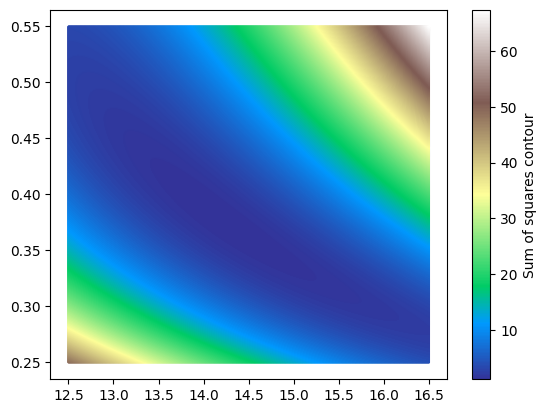

In [88]:
scatter = plt.scatter(x=df_21r['beta1'],y=df_21r['beta2'],c=df_21r['residual'], cmap='terrain', s=0.1)
cbar = plt.colorbar(scatter)
cbar.set_label('Sum of squares contour')

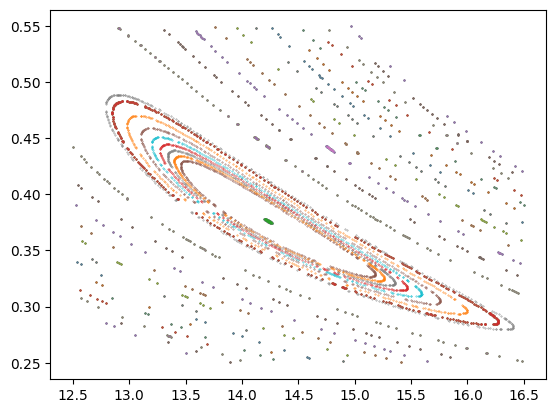

In [89]:
epsilon = 0.001
for i in np.linspace(0.6,0.95,8):
    SS = np.concat(([1.147], np.arange(2,30,2),[SSR_21 * (1 + 2/10*stats.f.isf(1-i,2,10))]))
    for ss in SS:

        mask = (df_21r['residual'] > ss - epsilon) & (df_21r['residual'] < ss + epsilon)
        # fig,ax=plt.subplots()
        df = df_21r[mask].sort_values('beta1')
        # ax.scatter(df['beta1'], df['beta2'],s=0.1)
        plt.scatter(df['beta1'], df['beta2'],s=0.1)



    # mask_21 = df_21r['residual']


### Problem 22

In [90]:
df_22 = pd.DataFrame({
    'x0': [1]*8,
    'x1': [(-1)**(i+1) for i in range(8)],
    'x2': [(-1)**(i//2+1) for i in range(8)],
    'y': [20,14,17,10,19,13,14,10]
})

df_22

,x0,x1,x2,y
0,1,-1,-1,20
1,1,1,-1,14
2,1,-1,1,17
3,1,1,1,10
4,1,-1,-1,19
5,1,1,-1,13
6,1,-1,1,14
7,1,1,1,10


In [91]:
X_22 = df_22[['x0','x1','x2']].to_numpy()
y_22 = df_22[['y']].to_numpy()

In [92]:
bs_22 = np.linalg.inv(X_22.T.dot(X_22)).dot(X_22.T).dot(y_22)
bs_22

array([[14.625],
       [-2.875],
       [-1.875]])

In [93]:
def func_22(x1,x2,bs):
    return np.array([1,x1,x2]).dot(bs)

In [94]:
ys_22 = []
x1_22, x2_22 = np.meshgrid(np.linspace(-5,5,101), np.linspace(-5,5,101))
for x1, x2 in zip(x1_22.flatten(), x2_22.flatten()):
    ys_22.append(func_22(x1,x2,bs_22)[0])

df_22contour = pd.DataFrame({
    'x1': x1_22.flatten(),
    'x2': x2_22.flatten(),
    'y': ys_22
})

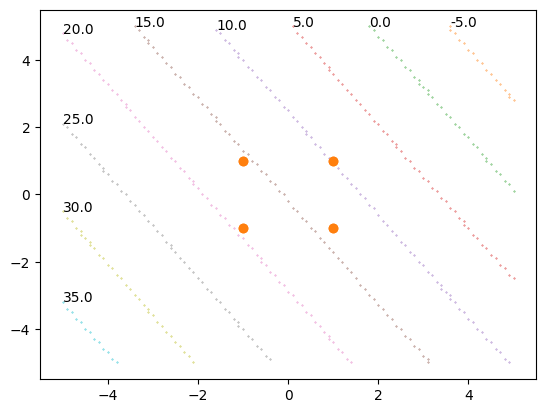

In [95]:
epsilon = 0.1
for i in np.linspace(-10,40,11):
    mask = (df_22contour['y'] > i-epsilon) & (df_22contour['y'] < i+epsilon)
    plt.scatter(df_22contour[mask]['x1'], df_22contour[mask]['x2'],s=0.1)
    plt.text(df_22contour[mask]['x1'].min(), df_22contour[mask]['x2'].max(), i)
plt.scatter(df_22['x1'], df_22['x2'])
# plt.legend()

### Problem 23

In [96]:
df_23 = pd.DataFrame({
    'temp':[150,160]*4,
    'conc': ([40]*2+[50]*2)*2,
    'pH': [6]*4+[7]*4
    })

df_23 = pd.concat((df_23,df_23)).reset_index(drop=True)
df_23.iloc[12,1] = 50
df_23['y'] = [73,75,78,82,75,76,87,89,70,74,80,82,82,79,85,88]
df_23

,temp,conc,pH,y
0,150,40,6,73
1,160,40,6,75
2,150,50,6,78
3,160,50,6,82
4,150,40,7,75
5,160,40,7,76
6,150,50,7,87
7,160,50,7,89
8,150,40,6,70
9,160,40,6,74


In [97]:
df_23['x0'] = [1]*16
df_23['x1'] = df_23['temp'].apply(lambda x: (x-155)/5)
df_23['x2'] = df_23['conc'].apply(lambda x: (x-45)/5)
df_23['x3'] = df_23['pH'].apply(lambda x: (x-6.5)/0.5)
df_23

,temp,conc,pH,y,x0,x1,x2,x3
0,150,40,6,73,1,-1.0,-1.0,-1.0
1,160,40,6,75,1,1.0,-1.0,-1.0
2,150,50,6,78,1,-1.0,1.0,-1.0
3,160,50,6,82,1,1.0,1.0,-1.0
4,150,40,7,75,1,-1.0,-1.0,1.0
5,160,40,7,76,1,1.0,-1.0,1.0
6,150,50,7,87,1,-1.0,1.0,1.0
7,160,50,7,89,1,1.0,1.0,1.0
8,150,40,6,70,1,-1.0,-1.0,-1.0
9,160,40,6,74,1,1.0,-1.0,-1.0


In [98]:
mean_23 = df_23['y'].mean()

In [99]:
effect1_23 = df_23.groupby('x1')['y'].mean().diff().values[1] / 2
effect1_23 # x1 effect -1 to 1, divided by 2 to get the corresponding linear regression coefficient

np.float64(0.9375)

In [100]:
effect2_23 = df_23.groupby('x2')['y'].mean().diff().values[1] / 2
effect2_23 #  effect -1 to 1, divided by 2 to get the corresponding linear regression coefficient

np.float64(4.547619047619051)

In [101]:
effect3_23 = df_23.groupby('x3')['y'].mean().diff().values[1] / 2
effect3_23 #  effect -1 to 1, divided by 2 to get the corresponding linear regression coefficient

np.float64(2.9375)

In [102]:
X_23 = df_23[['x0', 'x1', 'x2', 'x3']]
y_23 = df_23[['y']]
bs_23 = np.linalg.inv(X_23.T.dot(X_23)).dot(X_23.T).dot(y_23)
bs_23

array([[79.13319672],
       [ 1.49180328],
       [ 4.43442623],
       [ 2.38319672]])

In [103]:
df_23['y_hat_f'] = (mean_23 + effect1_23*df_23['x1'] + effect2_23*df_23['x2'] + effect3_23*df_23['x3'])
df_23['y_hat_lr'] = X_23.dot(bs_23)
df_23

,temp,conc,pH,y,x0,x1,x2,x3,y_hat_f,y_hat_lr
0,150,40,6,73,1,-1.0,-1.0,-1.0,71.264881,70.823770
1,160,40,6,75,1,1.0,-1.0,-1.0,73.139881,73.807377
2,150,50,6,78,1,-1.0,1.0,-1.0,80.360119,79.692623
3,160,50,6,82,1,1.0,1.0,-1.0,82.235119,82.676230
4,150,40,7,75,1,-1.0,-1.0,1.0,77.139881,75.590164
5,160,40,7,76,1,1.0,-1.0,1.0,79.014881,78.573770
6,150,50,7,87,1,-1.0,1.0,1.0,86.235119,84.459016
7,160,50,7,89,1,1.0,1.0,1.0,88.110119,87.442623
8,150,40,6,70,1,-1.0,-1.0,-1.0,71.264881,70.823770
9,160,40,6,74,1,1.0,-1.0,-1.0,73.139881,73.807377


In [104]:
((df_23['y'] - df_23['y_hat_f'])**2).sum(), ((df_23['y'] - df_23['y_hat_lr'])**2).sum() 

(np.float64(49.14044784580502), np.float64(33.4344262295082))

### Problem 24

In [105]:
df_24 = pd.DataFrame({
    'x': np.linspace(10,60,6),
    'y': [0.2,0.52,0.69,0.64,0.57,0.48]
})

df_24

,x,y
0,10.0,0.20
1,20.0,0.52
2,30.0,0.69
3,40.0,0.64
4,50.0,0.57
5,60.0,0.48


In [106]:
X_24 = df_24[['x']].to_numpy()
y_24 = df_24[['y']].to_numpy()

In [107]:
def func_24(beta1, beta2, x):
    return beta1/(beta1-beta2)*(np.exp(-beta2*x)-np.exp(-beta1*x))

In [108]:
# def search_min()

In [109]:
SS_24 = []
b1s_l_24=[]
b2s_l_24=[]
# b1s_24, b2s_24 = np.meshgrid(np.logspace(-2,1,10), np.logspace(-2,1,10))
b1s_24, b2s_24 = np.meshgrid(np.linspace(0.04,0.05,10), np.linspace(0.01,0.015,10))
for b1, b2 in zip(b1s_24.flatten(), b2s_24.flatten()):
    if b1 != b2:
        b1s_l_24.append(b1)
        b2s_l_24.append(b2)
        SS_24.append(((y_24 - func_24(b1,b2,X_24))**2).sum())

df_24r = pd.DataFrame({
    'beta1': b1s_l_24,
    'beta2': b2s_l_24,
    'residual': SS_24
})

In [110]:
df_24r.sort_values('residual')

,beta1,beta2,residual
64,0.044444,0.013333,0.035956
65,0.045556,0.013333,0.036093
53,0.043333,0.012778,0.036185
63,0.043333,0.013333,0.036187
54,0.044444,0.012778,0.036226
...,...,...,...
6,0.046667,0.010000,0.054086
19,0.050000,0.010556,0.056194
7,0.047778,0.010000,0.056654
8,0.048889,0.010000,0.059447


### Problem 26

In [111]:
df_26 = pd.DataFrame({
    'x1': [(-1)**(i+1) for i in range(8)] + [0]*4,
    'x2': [(-1)**(i//2+1) for i in range(8)] + [0]*4,
    'x3': [(-1)**(i//4+1) for i in range(8)] + [0]*4,
    'y': [10,11,4,4,9,10,5,3,6,7,8,7]

})

df_26

,x1,x2,x3,y
0,-1,-1,-1,10
1,1,-1,-1,11
2,-1,1,-1,4
3,1,1,-1,4
4,-1,-1,1,9
5,1,-1,1,10
6,-1,1,1,5
7,1,1,1,3
8,0,0,0,6
9,0,0,0,7


In [112]:
X_26 = np.concat(([[1]]*12, df_26[['x1','x2','x3']].to_numpy()),axis=1)
y_26 = df_26[['y']].to_numpy()

In [113]:
bs_26 = np.linalg.inv(X_26.T.dot(X_26)).dot(X_26.T).dot(y_26)
bs_26

array([[ 7.  ],
       [ 0.  ],
       [-3.  ],
       [-0.25]])

In [114]:
# estimate the variance of measurement by the last four 
y_26[-4:].var(ddof=1)

np.float64(0.6666666666666666)

In [115]:
# variance of the coefficients, degree of freedom 3
var_bs_26 = np.linalg.inv(X_26.T.dot(X_26)) * y_26[-4:].var(ddof=1)
se_bs_26 = np.sqrt(var_bs_26)
var_bs_26, se_bs_26

(array([[0.05555556, 0.        , 0.        , 0.        ],
        [0.        , 0.08333333, 0.        , 0.        ],
        [0.        , 0.        , 0.08333333, 0.        ],
        [0.        , 0.        , 0.        , 0.08333333]]),
 array([[0.23570226, 0.        , 0.        , 0.        ],
        [0.        , 0.28867513, 0.        , 0.        ],
        [0.        , 0.        , 0.28867513, 0.        ],
        [0.        , 0.        , 0.        , 0.28867513]]))

In [116]:
# only x2 has significant effect on the final results

### Problem 27

In [117]:
def func_27(x1, x2):
    return 89.3 + 16.48*x1 + 3.38*x2 - 16.5*x1**2 - 17.20*x2**2 - 6.99*x1*x2

In [118]:
x1_27, x2_27 = np.meshgrid(np.linspace(-5,0,101), np.linspace(-5,0,101))
y_27 = func_27(x1_27,x2_27)
df_27 = pd.DataFrame({
    'x1': x1_27.flatten(),
    'x2': x2_27.flatten(),
    'y': y_27.flatten()
})

In [119]:
df_27.sort_values('y', ascending=False)

,x1,x2,y
10200,0.00,0.00,89.300000
10099,0.00,-0.05,89.088000
9998,0.00,-0.10,88.790000
10199,-0.05,0.00,88.434750
9897,0.00,-0.15,88.406000
...,...,...,...
102,-4.95,-4.95,-1006.013725
202,-5.00,-4.90,-1006.389000
1,-4.95,-5.00,-1016.469750
101,-5.00,-4.95,-1016.776500


### Problem 28

In [120]:
df_28a = pd.DataFrame({
    f'x{i+1}': [(-1)**(j//(2**i)+1) for j in range(16)] for i in range(4)
})
df_28a['x5'] = df_28a[[f'x{i+1}' for i in range(4)]].prod(axis=1)
df_28a

,x1,x2,x3,x4,x5
0,-1,-1,-1,-1,1
1,1,-1,-1,-1,-1
2,-1,1,-1,-1,-1
3,1,1,-1,-1,1
4,-1,-1,1,-1,-1
5,1,-1,1,-1,1
6,-1,1,1,-1,1
7,1,1,1,-1,-1
8,-1,-1,-1,1,-1
9,1,-1,-1,1,1


In [121]:
df_28b = pd.DataFrame({
    f'x{i+1}': [0]*2*i + [-np.sqrt(2), np.sqrt(2)] + [0]*(10-2*i-2) for i in range(5)
})


In [122]:
df_28c = pd.DataFrame({
    f'x{i+1}': [0]*6 for i in range(5)
})

df_28c

,x1,x2,x3,x4,x5
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
5,0,0,0,0,0


In [123]:
df_28 = pd.concat((df_28a, df_28b, df_28c)).reset_index(drop=True)
df_28.round(1)

,x1,x2,x3,x4,x5
0,-1.0,-1.0,-1.0,-1.0,1.0
1,1.0,-1.0,-1.0,-1.0,-1.0
2,-1.0,1.0,-1.0,-1.0,-1.0
3,1.0,1.0,-1.0,-1.0,1.0
4,-1.0,-1.0,1.0,-1.0,-1.0
5,1.0,-1.0,1.0,-1.0,1.0
6,-1.0,1.0,1.0,-1.0,1.0
7,1.0,1.0,1.0,-1.0,-1.0
8,-1.0,-1.0,-1.0,1.0,-1.0
9,1.0,-1.0,-1.0,1.0,1.0


### Problem 29

In [124]:
df_29 = pd.DataFrame({
    'x1': [-1,0,1,-1,0,1,-1,0,1],
    'x2': [-1,-1,-1,0,0,0,1,1,1],
    'y': [1.3,0.4,1.0,1.2,1.,0.9,1.1,1.0,0.8]
})

df_29

,x1,x2,y
0,-1,-1,1.3
1,0,-1,0.4
2,1,-1,1.0
3,-1,0,1.2
4,0,0,1.0
5,1,0,0.9
6,-1,1,1.1
7,0,1,1.0
8,1,1,0.8


In [125]:
X_29 = np.concat(([[1]]*9, df_29[['x1','x2']].to_numpy()), axis=1)
y_29 = df_29[['y']].to_numpy()

In [126]:
bs_29 = np.linalg.inv(X_29.T.dot(X_29)).dot(X_29.T).dot(y_29)
bs_29

array([[ 0.96666667],
       [-0.15      ],
       [ 0.03333333]])

In [127]:
y_hat_29 = X_29.dot(bs_29)
y_hat_29

array([[1.08333333],
       [0.93333333],
       [0.78333333],
       [1.11666667],
       [0.96666667],
       [0.81666667],
       [1.15      ],
       [1.        ],
       [0.85      ]])

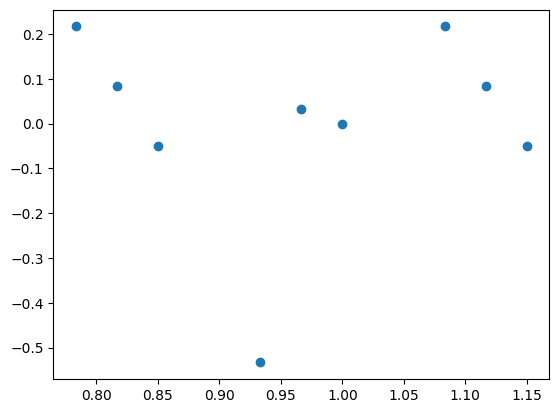

In [128]:
plt.scatter(y_hat_29, y_29 - y_hat_29)

In [129]:
residuals_29 =  y_29 - y_hat_29
SSR_29 = (residuals_29**2).sum() # 6 degree of freedom
MSR_29 = SSR_29 / 6
se_29 = np.sqrt(MSR_29)
MSR_29, se_29

(np.float64(0.0663888888888889), np.float64(0.2576604138956718))

In [130]:
np.linalg.inv(X_29.T.dot(X_29))*MSR_29, np.sqrt(np.linalg.inv(X_29.T.dot(X_29))*MSR_29)

(array([[0.00737654, 0.        , 0.        ],
        [0.        , 0.01106481, 0.        ],
        [0.        , 0.        , 0.01106481]]),
 array([[0.0858868 , 0.        , 0.        ],
        [0.        , 0.10518942, 0.        ],
        [0.        , 0.        , 0.10518942]]))

In [131]:
df_29_anova = pd.DataFrame({
    'items': ['total', 'model', 'mean', 'lr', 'residual'],
    'sum_squares': [(df_29['y']**2).sum(), (y_hat_29**2).sum(), 9*df_29['y'].mean()**2, ((y_hat_29-df_29['y'].mean())**2).sum(), SSR_29],
    'df': [9, 3, 1, 2, 6]
})

df_29_anova['mean_square'] = df_29_anova['sum_squares'] / df_29_anova['df']
df_29_anova

,items,sum_squares,df,mean_square
0,total,8.950000,9,0.994444
1,model,8.551667,3,2.850556
2,mean,8.410000,1,8.410000
3,lr,0.141667,2,0.070833
4,residual,0.398333,6,0.066389


In [132]:
# introduce quadble terms
df_29['x11'] = df_29['x1']**2
df_29['x22'] = df_29['x2']**2
df_29['x12'] = df_29['x1']*df_29['x2']
df_29

,x1,x2,y,x11,x22,x12
0,-1,-1,1.3,1,1,1
1,0,-1,0.4,0,1,0
2,1,-1,1.0,1,1,-1
3,-1,0,1.2,1,0,0
4,0,0,1.0,0,0,0
5,1,0,0.9,1,0,0
6,-1,1,1.1,1,1,-1
7,0,1,1.0,0,1,0
8,1,1,0.8,1,1,1


In [133]:
X_29b = np.concat(([[1]]*9, df_29[['x1','x2', 'x11', 'x22', 'x12']].to_numpy()), axis=1)


In [134]:
bs_29b = np.linalg.inv(X_29b.T.dot(X_29b)).dot(X_29b.T).dot(y_29)
bs_29b

array([[ 0.86666667],
       [-0.15      ],
       [ 0.03333333],
       [ 0.25      ],
       [-0.1       ],
       [ 0.        ]])

In [135]:
y_hat_29b = X_29b.dot(bs_29b)

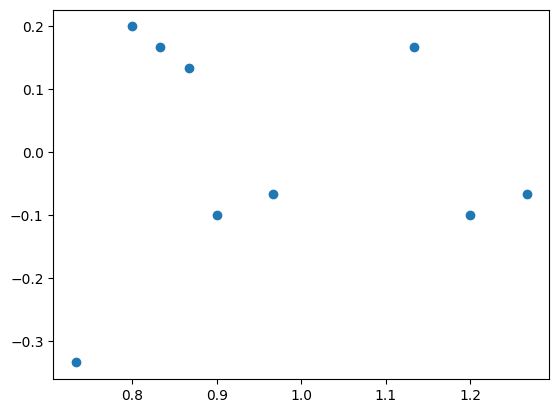

In [136]:
plt.scatter(y_hat_29b, y_29 - y_hat_29b)

In [137]:
residuals_29b =  y_29 - y_hat_29b
SSR_29b = (residuals_29b**2).sum() # 3 degree of freedom
MSR_29b = SSR_29b / 3
se_29b = np.sqrt(MSR_29b)
MSR_29b, se_29b

(np.float64(0.08444444444444445), np.float64(0.2905932629027116))

In [138]:
np.linalg.inv(X_29b.T.dot(X_29b))*MSR_29b, np.sqrt(np.linalg.inv(X_29b.T.dot(X_29b))*MSR_29b)

C:\Users\PeiguangHu\AppData\Local\Temp\ipykernel_25512\35952121.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.linalg.inv(X_29b.T.dot(X_29b))*MSR_29b, np.sqrt(np.linalg.inv(X_29b.T.dot(X_29b))*MSR_29b)


(array([[ 0.04691358,  0.        ,  0.        , -0.02814815, -0.02814815,
          0.        ],
        [ 0.        ,  0.01407407,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.        ,  0.        ,  0.01407407,  0.        ,  0.        ,
          0.        ],
        [-0.02814815,  0.        ,  0.        ,  0.04222222,  0.        ,
          0.        ],
        [-0.02814815,  0.        ,  0.        ,  0.        ,  0.04222222,
          0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.02111111]]),
 array([[0.21659543, 0.        , 0.        ,        nan,        nan,
         0.        ],
        [0.        , 0.1186342 , 0.        , 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.1186342 , 0.        , 0.        ,
         0.        ],
        [       nan, 0.        , 0.        , 0.20548047, 0.        ,
         0.        ],
        [       nan, 0.        , 0.        , 0.     

In [139]:
# remove the second factor remove the second data point 
X_29c = np.concat(([[1]]*9, df_29[['x1']].to_numpy()), axis=1)
X_29c = X_29c[[0,2,3,4,5,6,7,8]]
y_29c = y_29[[0,2,3,4,5,6,7,8]]

In [140]:
bs_29c = np.linalg.inv(X_29c.T.dot(X_29c)).dot(X_29c.T).dot(y_29c)
bs_29c

array([[ 1.0375],
       [-0.15  ]])

In [141]:
y_hat_29c = X_29c.dot(bs_29c)

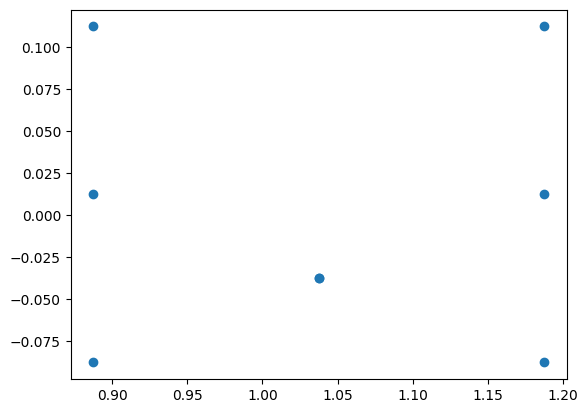

In [142]:
plt.scatter(y_hat_29c, y_29c - y_hat_29c)

In [143]:
# Now with replicates, we can calculate the standard errors
df_29c = df_29.iloc[[0,2,3,4,5,6,7,8], [0,2]]
SSE_29c = df_29c.groupby('x1')['y'].transform(lambda x: x.var(ddof=0)).sum() #degree of freedom 5
MSE_29c = SSE_29c / 5
SSE_29c, MSE_29c, np.sqrt(MSE_29c)

(np.float64(0.03999999999999998),
 np.float64(0.007999999999999997),
 np.float64(0.08944271909999157))

In [144]:
np.linalg.inv(X_29c.T.dot(X_29c)) * MSE_29c, np.sqrt(np.linalg.inv(X_29c.T.dot(X_29c)) * MSE_29c) # the x1 coefficient now is significant

(array([[0.001     , 0.        ],
        [0.        , 0.00133333]]),
 array([[0.03162278, 0.        ],
        [0.        , 0.03651484]]))

In [145]:
residuals_29c =  y_29c - y_hat_29c
SSR_29c = (residuals_29c**2).sum() #  degree of freedom 6
SSL_29c = SSR_29c - SSE_29c # lack of fit, degree of freedom 1
MSL_29c = SSL_29c
SSR_29c, MSL_29c, np.sqrt(MSL_29c)

(np.float64(0.04374999999999998),
 np.float64(0.0037500000000000033),
 np.float64(0.06123724356957948))

In [146]:
stats.f.sf(MSL_29c/MSE_29c, dfn=2, dfd=5) # no lack of fit

np.float64(0.6507526633890723)

### Problem 30

In [147]:
df_30 = pd.DataFrame({
    'x1': [-1,1,-1,1,-2,2,0,0,0],
    'x2': [-1,-1,1,1,0,0,-2,2,0],
    'y': [2,4,3,5,1,4,1,5,3]
})
df_30

,x1,x2,y
0,-1,-1,2
1,1,-1,4
2,-1,1,3
3,1,1,5
4,-2,0,1
5,2,0,4
6,0,-2,1
7,0,2,5
8,0,0,3


In [148]:
df_30['x11'] = df_30['x1']**2
df_30['x22'] = df_30['x2']**2
df_30['x12'] = df_30['x1']*df_30['x2']
df_30

,x1,x2,y,x11,x22,x12
0,-1,-1,2,1,1,1
1,1,-1,4,1,1,-1
2,-1,1,3,1,1,-1
3,1,1,5,1,1,1
4,-2,0,1,4,0,0
5,2,0,4,4,0,0
6,0,-2,1,0,4,0
7,0,2,5,0,4,0
8,0,0,3,0,0,0


In [149]:
X_30 = np.concat(([[1]]*9, df_30[['x1','x2', 'x11', 'x22', 'x12']].to_numpy()), axis=1)
y_30 = df_30[['y']].to_numpy()

In [150]:
bs_30 = np.linalg.inv(X_30.T.dot(X_30)).dot(X_30.T).dot(y_30)
bs_30

array([[ 3.55555556],
       [ 0.83333333],
       [ 0.83333333],
       [-0.22916667],
       [-0.10416667],
       [ 0.        ]])

In [151]:
y_hat_30 = X_30.dot(bs_30)
residual_30 = y_30 - y_hat_30
SSR_30 = (residual_30**2).sum()
MSR_30 = SSR_30 / 3
MSR_30, np.sqrt(MSR_30)

(np.float64(0.5092592592592594), np.float64(0.7136240321480628))

In [152]:
(np.linalg.inv(X_30.T.dot(X_30))*MSR_30).diagonal(), np.sqrt((np.linalg.inv(X_30.T.dot(X_30))*MSR_30).diagonal()) # seems the second degree coefficients are not significant

(array([0.28292181, 0.04243827, 0.04243827, 0.03978588, 0.03978588,
        0.12731481]),
 array([0.53190395, 0.20600551, 0.20600551, 0.19946398, 0.19946398,
        0.35681202]))

In [153]:
# now fit the first-degree model
X_30b = np.concat(([[1]]*9, df_30[['x1','x2']].to_numpy()), axis=1)

In [154]:
bs_30b = np.linalg.inv(X_30b.T.dot(X_30b)).dot(X_30b.T).dot(y_30)
bs_30b

array([[3.11111111],
       [0.83333333],
       [0.83333333]])

In [155]:
y_hat_30b = X_30b.dot(bs_30b)
residual_30b = y_30 - y_hat_30b
SSR_30b = (residual_30b**2).sum()
MSR_30b = SSR_30b / 6
MSR_30b, np.sqrt(MSR_30b) # degree of freedom 

(np.float64(0.37037037037037024), np.float64(0.6085806194501845))

In [156]:
(np.linalg.inv(X_30b.T.dot(X_30b))*MSR_30b).diagonal(), np.sqrt((np.linalg.inv(X_30b.T.dot(X_30b))*MSR_30b).diagonal()) # 

(array([0.04115226, 0.0308642 , 0.0308642 ]),
 array([0.20286021, 0.17568209, 0.17568209]))

### Problem 31

In [157]:
df_31 = pd.DataFrame({
    'temp': [160,180]*4,
    'pH': [6,6,7,7]*2,
    'cat': [4,4,4,4]+[6,6,6,6],
    'y': [42,50,39,50,60,69,60,70]
})

In [158]:
# a
yates_algor(df_31.y, 3)

0    55.0
1     9.5
2    -0.5
3     1.0
4    19.5
5     0.0
6     1.0
7    -0.5
Name: y, dtype: float64

In [159]:
# b
e_var_31 = 4/8 * 1
e_var_31, np.sqrt(e_var_31)

(0.5, np.float64(0.7071067811865476))

In [160]:
#c
df_31['x1'] = (df_31['temp'] - 170)/10
df_31['x2'] = (df_31['cat'] - 5) / 1

X_31 = np.concat(([[1]]*8, df_31[['x1','x2']].to_numpy()), axis=1)
y_31 = df_31[['y']].to_numpy()
X_31, y_31

(array([[ 1., -1., -1.],
        [ 1.,  1., -1.],
        [ 1., -1., -1.],
        [ 1.,  1., -1.],
        [ 1., -1.,  1.],
        [ 1.,  1.,  1.],
        [ 1., -1.,  1.],
        [ 1.,  1.,  1.]]),
 array([[42],
        [50],
        [39],
        [50],
        [60],
        [69],
        [60],
        [70]]))

In [161]:
bs_31 = np.linalg.inv(X_31.T.dot(X_31)).dot(X_31.T).dot(y_31)
bs_31

array([[55.  ],
       [ 4.75],
       [ 9.75]])

In [162]:
#d since now we omit pH, we have two replicate for each combination of temp and cat. degree of freedom 4
SSE_31 = df_31.groupby(['temp', 'cat'])['y'].transform(lambda x: x.var(ddof=0)).sum()
MSE_31 = SSE_31 / 4 # close to the approximation

# residual
y_hat_31 = X_31.dot(bs_31)
SSR_31 = ((y_31 - y_hat_31)**2).sum() # degree of freedom 5

# lack of fit check degree of freedom 1
SSL_31 = SSR_31 - SSE_31
MSL_31 = SSL_31 / 1

SSR_31, SSE_31, MSE_31, MSL_31, stats.f.sf(MSL_31/MSE_31, dfn=1, dfd=4)

(np.float64(5.0),
 np.float64(5.0),
 np.float64(1.25),
 np.float64(0.0),
 np.float64(1.0))

In [163]:
(np.linalg.inv(X_31.T.dot(X_31)) * 1).diagonal(), np.sqrt((np.linalg.inv(X_31.T.dot(X_31)) * 1).diagonal())

(array([0.125, 0.125, 0.125]), array([0.35355339, 0.35355339, 0.35355339]))

In [164]:
#d it is adequately fit
#e yes 1.25 vs 1

In [165]:
#f
def func_31(x1,x2):
    return np.concat(([[1]]*len(x1.reshape(-1,1)), x1.reshape(-1,1), x2.reshape(-1,1)),axis=1).dot(bs_31)

In [166]:
x1s_31, x2s_31 = np.meshgrid(np.linspace(0,10,1001), np.linspace(0,10,1001))
ys_31 = func_31(x1s_31.flatten(), x2s_31.flatten())
df_31f = pd.DataFrame({
    'x1': x1s_31.flatten(), 
    'x2': x2s_31.flatten(),
    'y': ys_31.flatten()
})

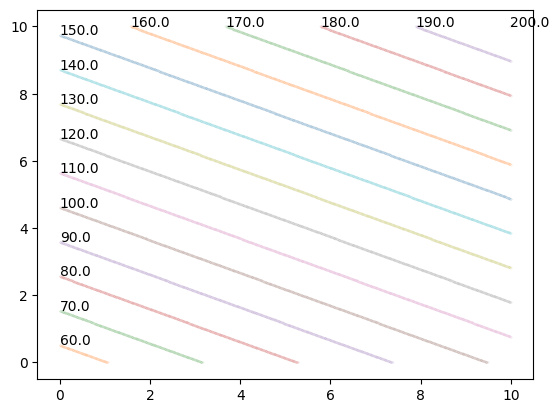

In [167]:
epsilon = 0.1
for i in np.linspace(50, 200, 16):
    mask = (df_31f['y'] > i-epsilon) & (df_31f['y'] < i+epsilon)
    plt.scatter(df_31f[mask]['x1'], df_31f[mask]['x2'], s=0.001)
    plt.text(df_31f[mask]['x1'].min(), df_31f[mask]['x2'].max(), i)


In [168]:
# next two settings. 
bs_31
# try x1 = 2, x2=2.053*2

array([[55.  ],
       [ 4.75],
       [ 9.75]])

### Problem 32
The change in the results is too small. may not give accurate information

In [169]:
df_32 = pd.DataFrame({
    'x1': [-1,1,-1,1,-2,2,0,0,0,0],
    'x2': [-1,-1,1,1,0,0,-2,2,0,0],
    'y': [74,74,72,73,71,72,75,71,73,75]
})

In [170]:
X_32 = np.concat(([[1]]*10, df_32[['x1','x2']].to_numpy()), axis=1)
y_32 = df_32[['y']].to_numpy()

In [171]:
bs_32 = np.linalg.inv(X_32.T.dot(X_32)).dot(X_32.T.dot(y_32))
bs_32

array([[73.        ],
       [ 0.25      ],
       [-0.91666667]])

In [172]:
# use the replicates to estimate the standard deviation
se_32 = y_32[-2:].var(ddof=1)
se_32

np.float64(2.0)

In [173]:
# parameter standard errors
(np.linalg.inv(X_32.T.dot(X_32))*se_32).diagonal(), np.sqrt(np.linalg.inv(X_32.T.dot(X_32))*se_32).diagonal()

(array([0.2       , 0.16666667, 0.16666667]),
 array([0.4472136 , 0.40824829, 0.40824829]))

In [174]:
def func_32(x1,x2):
    return np.concat(([[1]]*len(x1.reshape(-1,1)), x1.reshape(-1,1), x2.reshape(-1,1)),axis=1).dot(bs_32)

In [175]:
x1s_32, x2s_32 = np.meshgrid(np.linspace(-2,3,501), np.linspace(-2,3,501))
ys_32 = func_32(x1s_32.flatten(), x2s_32.flatten())
df_32f = pd.DataFrame({
    'x1': x1s_32.flatten(), 
    'x2': x2s_32.flatten(),
    'y': ys_32.flatten()
})

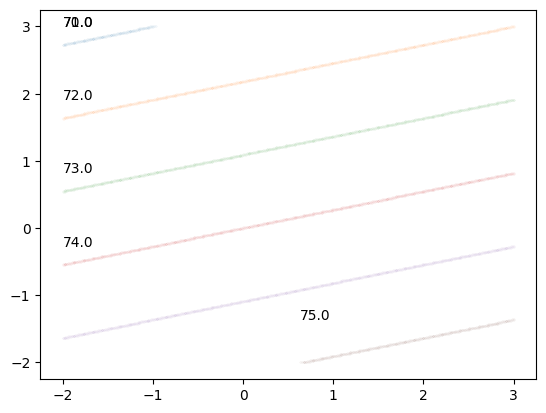

In [176]:
epsilon = 0.01
for i in np.linspace(70,75,6):
    mask = (df_32f['y'] > i-epsilon) & (df_32f['y'] < i+epsilon)
    plt.scatter(df_32f[mask]['x1'], df_32f[mask]['x2'], s=0.001)
    plt.text(df_32f[mask]['x1'].min(), df_32f[mask]['x2'].max(), i)

### Problem 33

In [177]:
df_33 = pd.DataFrame({
    f'x{i+1}': [(-1)**(j//2**i+1) for j in range(8)] + [0]*2*i + [-2,2] + [0]*(16-8-2*i-2) for i in range(3)
})
df_33['x0'] = 1
df_33

,x1,x2,x3,x0
0,-1,-1,-1,1
1,1,-1,-1,1
2,-1,1,-1,1
3,1,1,-1,1
4,-1,-1,1,1
5,1,-1,1,1
6,-1,1,1,1
7,1,1,1,1
8,-2,0,0,1
9,2,0,0,1


In [178]:
second_degree_33 = []
from itertools import combinations_with_replacement as cwr 
second_degree_33.extend(cwr([f'x{i+1}' for i in range(3)], 2))
second_degree_33

[('x1', 'x1'),
 ('x1', 'x2'),
 ('x1', 'x3'),
 ('x2', 'x2'),
 ('x2', 'x3'),
 ('x3', 'x3')]

In [179]:
for second_degree in second_degree_33:
    df_33[''.join(second_degree)] = df_33[list(second_degree)].prod(axis=1)

df_33

,x1,x2,x3,x0,x1x1,x1x2,x1x3,x2x2,x2x3,x3x3
0,-1,-1,-1,1,1,1,1,1,1,1
1,1,-1,-1,1,1,-1,-1,1,1,1
2,-1,1,-1,1,1,-1,1,1,-1,1
3,1,1,-1,1,1,1,-1,1,-1,1
4,-1,-1,1,1,1,1,-1,1,-1,1
5,1,-1,1,1,1,-1,1,1,-1,1
6,-1,1,1,1,1,-1,-1,1,1,1
7,1,1,1,1,1,1,1,1,1,1
8,-2,0,0,1,4,0,0,0,0,0
9,2,0,0,1,4,0,0,0,0,0


### Problem 34

In [180]:
df_34 = pd.DataFrame({
    'x1': [-1,-1,-1,0,0,0,1,1,1],
    'x2': [-1,0,1,-1,0,1,-1,0,1],
    'y': [21.1,23.7,20.7,21.1,24.1,22.2,18.4,23.4,21.9],
    't': [150,10,8,35,8,7,18,8,10]
})

df_34

,x1,x2,y,t
0,-1,-1,21.1,150
1,-1,0,23.7,10
2,-1,1,20.7,8
3,0,-1,21.1,35
4,0,0,24.1,8
5,0,1,22.2,7
6,1,-1,18.4,18
7,1,0,23.4,8
8,1,1,21.9,10


In [181]:
X_34 = np.concat(([[1]]*9, df_34[['x1','x2']].to_numpy()), axis=1)
y_34 = df_34[['y']].to_numpy()
t_34 = df_34[['t']].to_numpy()

In [182]:
ybs_34 = np.linalg.inv(X_34.T.dot(X_34)).dot(X_34.T).dot(y_34)
tbs_34 = np.linalg.inv(X_34.T.dot(X_34)).dot(X_34.T).dot(t_34)
ybs_34, tbs_34

(array([[21.84444444],
        [-0.3       ],
        [ 0.7       ]]),
 array([[ 28.22222222],
        [-22.        ],
        [-29.66666667]]))

In [183]:
def func_34(x1,x2,bs):
    return np.concat(([[1]]*len(x1.reshape(-1,1)), x1.reshape(-1,1), x2.reshape(-1,1)),axis=1).dot(bs)

In [184]:
x1s_34, x2s_34 = np.meshgrid(np.linspace(-2,3,501), np.linspace(-2,3,501))
ys_34 = func_34(x1s_34.flatten(), x2s_34.flatten(), ybs_34)
ts_34 = func_34(x1s_34.flatten(), x2s_34.flatten(), tbs_34)
df_34f = pd.DataFrame({
    'x1': x1s_34.flatten(), 
    'x2': x2s_34.flatten(),
    'y': ys_34.flatten(),
    't': ts_34.flatten()
})

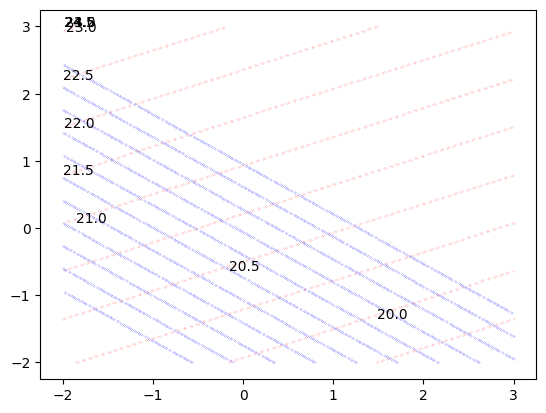

In [185]:
epsilon = 0.001
fig_34, ax_34 = plt.subplots()
for i in np.linspace(18,25,15):
    mask = (df_34f['y'] > i-epsilon) & (df_34f['y'] < i+epsilon)
    ax_34.scatter(df_34f[mask]['x1'], df_34f[mask]['x2'], s=0.01,c='r')
    ax_34.text(df_34f[mask]['x1'].min(), df_34f[mask]['x2'].max(), i)

epsilon = 0.1
for i in np.linspace(0,100,11):
    mask = (df_34f['t'] > i-epsilon) & (df_34f['t'] < i+epsilon)
    ax_34.scatter(df_34f[mask]['x1'], df_34f[mask]['x2'], s=0.01,c='b')
    # ax_34.text(df_34f[mask]['x1'].min(), df_34f[mask]['x2'].max(), i)

### Problem 35

In [186]:
df_35a = pd.DataFrame({
    f'x{i+1}': [(-1)**(j//2**i+1) for j in range(16)] for i in range(4)
})
df_35a['x1'] = df_35a['x1']*11.45 + 21.05
df_35a['x2'] = df_35a['x2']*15 + 55
df_35a['x3'] = df_35a['x3']*15 + 320
df_35a['x4'] = df_35a['x4']*1.5 + 6

df_35a

,x1,x2,x3,x4
0,9.6,40,305,4.5
1,32.5,40,305,4.5
2,9.6,70,305,4.5
3,32.5,70,305,4.5
4,9.6,40,335,4.5
5,32.5,40,335,4.5
6,9.6,70,335,4.5
7,32.5,70,335,4.5
8,9.6,40,305,7.5
9,32.5,40,305,7.5


In [187]:
df_35b = pd.DataFrame({
    'x1': [60,5]+[17.5]*7,
    'x2': [55,55,85]+[25]*6,
    'x3': [320]*4+[350,290]+[320]*3,
    'x4': [6.0]*6+[9.0,3.0,6.0]})

df_35 = pd.concat((df_35a, df_35b), axis=0).reset_index(drop=True)
df_35['y'] = np.array([51,28,65,51,24,38,45,49,30,35,45,82,24,54,35,51,53,56,67,45,51,23,51,47,32])/100
df_35

,x1,x2,x3,x4,y
0,9.6,40,305,4.5,0.51
1,32.5,40,305,4.5,0.28
2,9.6,70,305,4.5,0.65
3,32.5,70,305,4.5,0.51
4,9.6,40,335,4.5,0.24
5,32.5,40,335,4.5,0.38
6,9.6,70,335,4.5,0.45
7,32.5,70,335,4.5,0.49
8,9.6,40,305,7.5,0.30
9,32.5,40,305,7.5,0.35


In [188]:
X_35 = np.concat(([[1]]*25, df_35[['x1','x2','x3','x4']].to_numpy()), axis=1)
y_35 = df_35[['y']].to_numpy()

In [189]:
bs_35 = np.linalg.inv(X_35.T.dot(X_35)).dot(X_35.T.dot(y_35))
bs_35

array([[ 3.09448066e-01],
       [ 1.84304123e-03],
       [ 3.69001601e-03],
       [-3.05555556e-04],
       [ 3.61111111e-03]])

In [190]:
(np.linalg.inv(X_35.T.dot(X_35))*0.00845).diagonal()

array([1.69169843e-01, 2.14997764e-06, 9.46088199e-07, 1.56481481e-06,
       1.56481481e-04])

In [191]:
# estimate the standard error with two replicates. sample size might be too small
df_35.iloc[:,:4].value_counts(), np.array([0.45, 0.32]).var(ddof=1), np.array([0.45, 0.32]).std(ddof=1)

(x1    x2  x3   x4 
 17.5  25  320  6.0    2
 9.6   40  305  4.5    1
 32.5  40  305  4.5    1
 9.6   70  305  4.5    1
 32.5  70  305  4.5    1
 9.6   40  335  4.5    1
 32.5  40  335  4.5    1
 9.6   70  335  4.5    1
 32.5  70  335  4.5    1
 9.6   40  305  7.5    1
 32.5  40  305  7.5    1
 9.6   70  305  7.5    1
 32.5  70  305  7.5    1
 9.6   40  335  7.5    1
 32.5  40  335  7.5    1
 9.6   70  335  7.5    1
 32.5  70  335  7.5    1
 60.0  55  320  6.0    1
 5.0   55  320  6.0    1
 17.5  85  320  6.0    1
       25  350  6.0    1
           290  6.0    1
           320  9.0    1
                3.0    1
 Name: count, dtype: int64,
 np.float64(0.008450000000000001),
 np.float64(0.09192388155425119))

In [192]:
y_hat_35 = X_35.dot(bs_35)
df_35['y_hat'] = y_hat_35
df_35

,x1,x2,x3,x4,y,y_hat
0,9.6,40,305,4.5,0.51,0.397797
1,32.5,40,305,4.5,0.28,0.440003
2,9.6,70,305,4.5,0.65,0.508498
3,32.5,70,305,4.5,0.51,0.550704
4,9.6,40,335,4.5,0.24,0.388631
5,32.5,40,335,4.5,0.38,0.430836
6,9.6,70,335,4.5,0.45,0.499331
7,32.5,70,335,4.5,0.49,0.541537
8,9.6,40,305,7.5,0.30,0.408631
9,32.5,40,305,7.5,0.35,0.450836


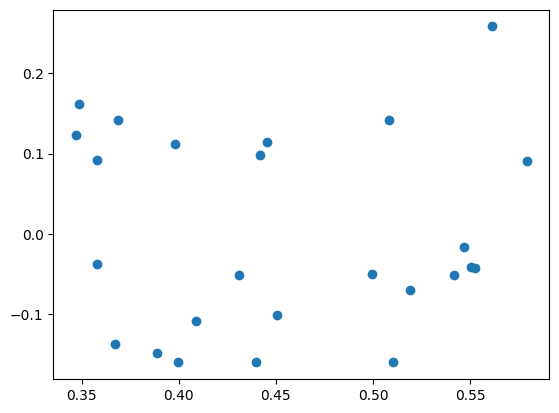

In [193]:
# check residuals
plt.scatter(df_35['y_hat'], df_35['y'] - df_35['y_hat'])

([<matplotlib.axis.YTick at 0x20876613390>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

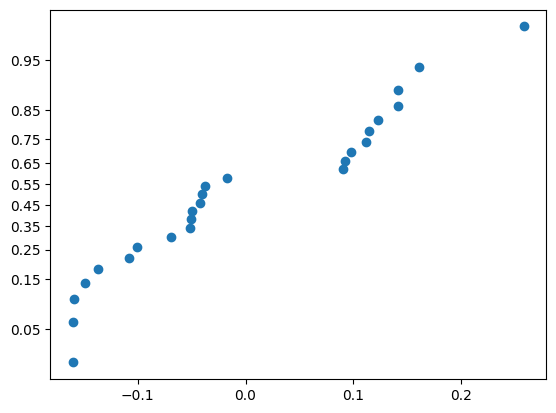

In [194]:
# check residual normality
plt.scatter((df_35['y'] - df_35['y_hat']).sort_values(), -stats.norm.isf(np.linspace(0,1,26)[:-1] + 1/25/2))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

In [195]:
((df_35['y'] - df_35['y_hat'])**2).sum() / (25-5), np.sqrt(((df_35['y'] - df_35['y_hat'])**2).sum() / (25-5)) # similar to the error from the replicates

(np.float64(0.017860660499684385), np.float64(0.1336437821212958))

In [196]:
x1_35, x3_35 = np.meshgrid(np.linspace(5,60,111), np.linspace(290,350,111))

In [197]:
def contour_36(x1, x2, x3, x4):
    fig,ax=plt.subplots()
    y = np.concat(([[1]]*len(x1), x1, x2, x3, x4),axis=1).dot(bs_35)
    ys = np.linspace(y.min(), y.max(), 10)
    epsilon = 0.0001
    for y0 in ys:
        mask = (y > y0 - epsilon) & (y < y0 + epsilon)
        ax.scatter(x1[mask],x3[mask], color='b', s=0.1)
        ax.text(x1[mask].min(),x3[mask].min(), y0.round(3))



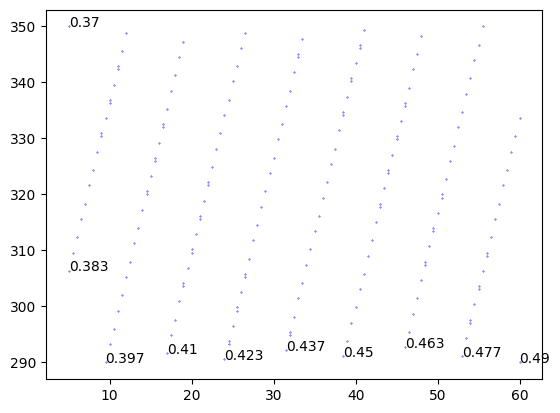

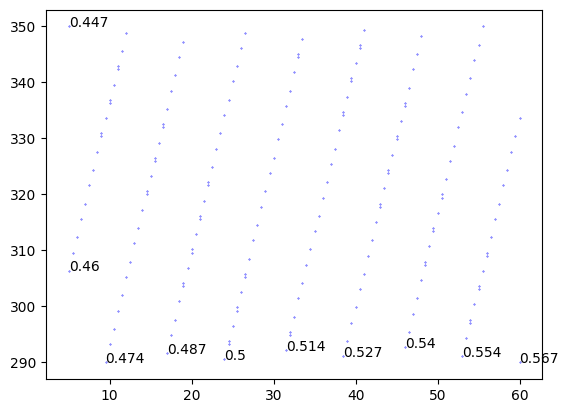

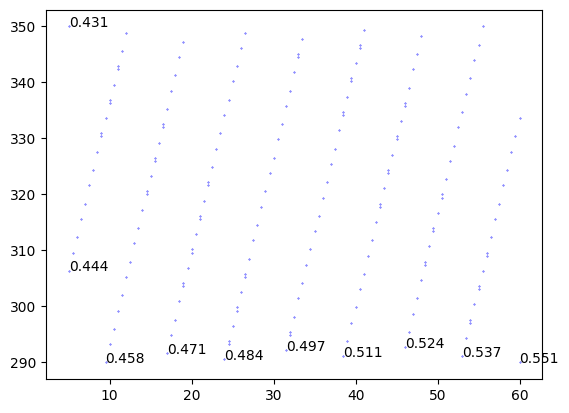

In [198]:
for x2,x4 in zip([40,55,55],[3,9,4.5]):
    contour_36(x1_35.reshape(-1,1), [[x2]]*len(x1_35.flatten()), x3_35.reshape(-1,1), [[x4]]*len(x1_35.flatten()))

### Problem 36

In [199]:
# df_36 = pd.DataFrame({
#     'temp': [70,110,70,110,60,120,90,90,90,90,90],
#     'conc': [21,21,25,25,23,23,20,26,23,23,23],
#     'y': [78.0,79.7,79.3,79.1,78.5,80.2,78.2,80.2,80.0,80.3,80.2]
# })

df_36 = pd.DataFrame({
    'temp': [70,110,70,110,60,120,90,90,90,90,90],
    'conc': [21,21,25,25,23,23,20,26,23,23,23],
    'y': [78.0,79.7,79.3,79.1,78.5,80.2,78.2,80.2,79.5,80.8,80.2]
})

df_36['x0'] = [1]*11
df_36['x1'] = (df_36['temp']-90)/20
df_36['x2'] = (df_36['conc']-23)/2

df_36['x11'] = df_36['x1']**2
df_36['x22'] = df_36['x2']**2
df_36['x12'] = df_36['x1']*df_36['x2']
df_36


,temp,conc,y,x0,x1,x2,x11,x22,x12
0,70,21,78.0,1,-1.0,-1.0,1.00,1.00,1.0
1,110,21,79.7,1,1.0,-1.0,1.00,1.00,-1.0
2,70,25,79.3,1,-1.0,1.0,1.00,1.00,-1.0
3,110,25,79.1,1,1.0,1.0,1.00,1.00,1.0
4,60,23,78.5,1,-1.5,0.0,2.25,0.00,-0.0
5,120,23,80.2,1,1.5,0.0,2.25,0.00,0.0
6,90,20,78.2,1,0.0,-1.5,0.00,2.25,-0.0
7,90,26,80.2,1,0.0,1.5,0.00,2.25,0.0
8,90,23,79.5,1,0.0,0.0,0.00,0.00,0.0
9,90,23,80.8,1,0.0,0.0,0.00,0.00,0.0


In [201]:
X_36 = df_36[['x0','x1','x2','x11','x22','x12']].to_numpy()
y_36 = df_36[['y']].to_numpy()

In [202]:
bs_36 = np.linalg.inv(X_36.T.dot(X_36)).dot(X_36.T.dot(y_36))
bs_36

array([[80.138041  ],
       [ 0.47647059],
       [ 0.43529412],
       [-0.42657555],
       [-0.49324222],
       [-0.475     ]])

In [203]:
# estimate the standard error from replicates, 2 degree of freedom
mse_36 = y_36[-3:].var(ddof=1)
sse_36 = mse_36 * 2
se_36 = y_36[-3:].std(ddof=1)
mse_36

np.float64(0.4233333333333316)

In [204]:
(np.linalg.inv(X_36.T.dot(X_36))*y_36[-3:].var(ddof=1)).diagonal(), np.sqrt((np.linalg.inv(X_36.T.dot(X_36))*y_36[-3:].var(ddof=1)).diagonal())

(array([0.13982536, 0.04980392, 0.04980392, 0.06333511, 0.06333511,
        0.10583333]),
 array([0.37393229, 0.22316792, 0.22316792, 0.25166469, 0.25166469,
        0.32532035]))

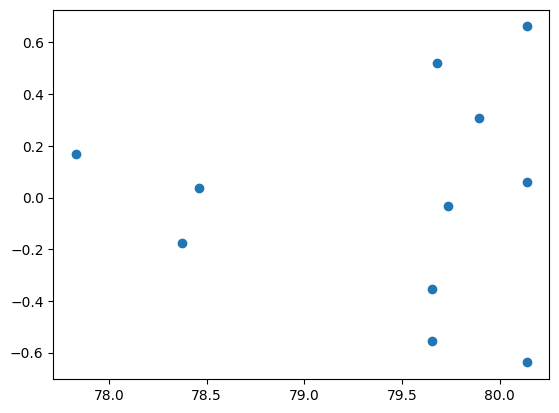

In [205]:
# residuals with 5 degree of freedom
y_hat_36 = X_36.dot(bs_36)
residuals_36 = y_36 - y_hat_36
plt.scatter(y_hat_36, residuals_36)

([<matplotlib.axis.YTick at 0x2087a5a6ad0>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

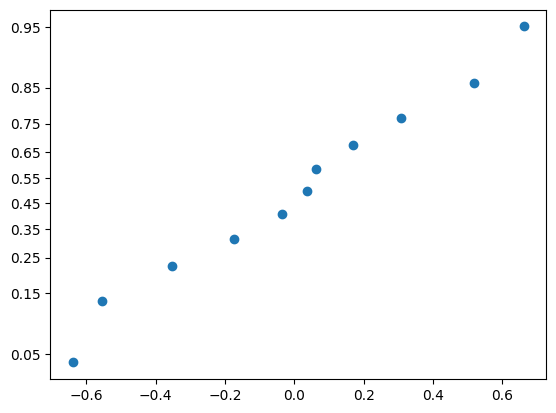

In [206]:
plt.scatter(sorted(residuals_36), -stats.norm.isf(np.linspace(0,1,12)[:-1]+1/12/2))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

In [207]:
ssr_36 = (residuals_36**2).sum()
ssl_36 = ssr_36 - sse_36 # 3 degree of freedom
msl_36 = ssl_36 / 3
msl_36


np.float64(0.2865009230723522)

In [208]:
stats.f.sf(msl_36/mse_36, dfn=3, dfd=2) # the model is adequate

np.float64(0.6424492579318046)

In [209]:
# map the vicinity
temps_36, concs_36 = np.meshgrid(np.linspace(60,120,601), np.linspace(20,26,601))
x1_36 =(temps_36-90).reshape(-1,1)/20
x2_36 = (concs_36-23).reshape(-1,1)/2

In [210]:
X_36_map = np.concat(([[1]]*len(x1_36), x1_36, x2_36, x1_36**2, x2_36**2, x1_36*x2_36),axis=1)
y_36_map = X_36_map.dot(bs_36)

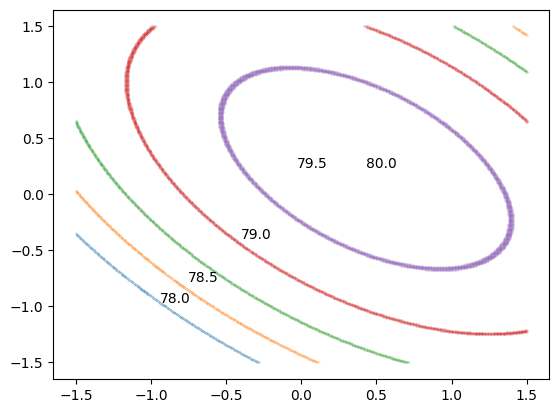

In [211]:
epsilon = 0.01
for y0 in np.linspace(78,81,7):
    mask = (y_36_map > y0 - epsilon) & (y_36_map < y0 + epsilon)
    if len(x1_36[mask]) > 0:
        # print(x1_36[mask].size)
        plt.scatter(x1_36[mask], x2_36[mask], s=0.01)
        plt.text(np.median(x1_36[mask]), np.median(x2_36[mask]), y0)

In [212]:
# with the new data, the model is adequate. however, the factor effects are not significant

### Problem 37

| | A (moles/liter) | B (moles/liter) | C (mmoles/liter) | D (C) |
| - | - | - | - | - |
| + | 40 | 2 | 1.0 | 175 |
| - | 20 | 1 | 0.5 | 165 |

In [213]:
factors_37 = 'ABCD'
df_37a = pd.DataFrame({
    f'{factors_37[i]}': [(-1)**(j//2**i+1) for j in range(16)] for i in range(4)
})

df_37b = pd.DataFrame({
    't1': [3.17,14.7,4.80,23.2,3.72,17.9,8.6,30.9,7.48,25.3,13.3,50.8,9.15,30.8,22.8,62.6],
    't2': [5.39,23.4,10.8,39.0,3.81,28.3,13.3,51.4,9.93,35.3,27.1,75.6,15.8,44.4,37.2,88.0],
    't3': [8.66,34.3,22.5,55.6,17.2,40.5,25.9,72.2,20.0,39.1,43.0,84.2,27.5,46.7,57.9,89.5],
    't4': [15.9,34.6,34.6,63.4,20.0,34.2,39.8,76.4,30.9,28.4,58.0,57.0,33.9,24.9,69.1,43.4],
    't5': [22.6,20.3,42.0,41.6,23.9,21.6,50.8,38.9,24.9,7.5,49.4,11.5,23.0,2.94,53.9,5.80]
})

df_37 = pd.merge(df_37a, df_37b, left_index=True, right_index=True)#.reset_index(drop=True)
df_37

,A,B,C,D,t1,t2,t3,t4,t5
0,-1,-1,-1,-1,3.17,5.39,8.66,15.9,22.60
1,1,-1,-1,-1,14.70,23.40,34.30,34.6,20.30
2,-1,1,-1,-1,4.80,10.80,22.50,34.6,42.00
3,1,1,-1,-1,23.20,39.00,55.60,63.4,41.60
4,-1,-1,1,-1,3.72,3.81,17.20,20.0,23.90
5,1,-1,1,-1,17.90,28.30,40.50,34.2,21.60
6,-1,1,1,-1,8.60,13.30,25.90,39.8,50.80
7,1,1,1,-1,30.90,51.40,72.20,76.4,38.90
8,-1,-1,-1,1,7.48,9.93,20.00,30.9,24.90
9,1,-1,-1,1,25.30,35.30,39.10,28.4,7.50


In [214]:
df_factors_37 = pd.DataFrame()
for i in np.arange(5)+1:
    df_factors_37[f't{i}'] = yates_algor(df_37[f't{i}'],4)

In [215]:
df_factors_37

,t1,t2,t3,t4,t5
0,20.57625,31.795625,42.7975,41.53125,27.540
1,22.89750,32.758750,29.9300,7.51250,-17.545
2,13.09750,22.008750,27.1050,27.36250,18.395
3,6.60250,8.641250,8.1200,2.16250,-7.030
4,5.46500,6.961250,8.7550,2.36250,0.130
5,1.58500,2.738750,0.1700,-3.48750,-3.045
6,2.73500,2.388750,1.2950,1.56250,1.095
7,-0.03500,0.311250,0.7300,-0.73750,-2.380
8,14.40500,19.741250,16.3800,3.33750,-10.345
9,6.29500,5.558750,-2.1550,-17.06250,-13.320


In [216]:
df_37_1s = df_37[df_37==1]
combs_37 = []
for i in range(16):
    combs_37.append(''.join(df_37_1s.iloc[i][df_37_1s.iloc[i] == 1].index))
combs_37[0] = 'aveage'
combs_37

['aveage',
 'A',
 'B',
 'AB',
 'C',
 'AC',
 'BC',
 'ABC',
 'D',
 'AD',
 'BD',
 'ABD',
 'CD',
 'ACD',
 'BCD',
 'ABCD']

In [217]:
df_factors_37.index=combs_37
df_factors_37

,t1,t2,t3,t4,t5
aveage,20.57625,31.795625,42.7975,41.53125,27.540
A,22.89750,32.758750,29.9300,7.51250,-17.545
B,13.09750,22.008750,27.1050,27.36250,18.395
AB,6.60250,8.641250,8.1200,2.16250,-7.030
C,5.46500,6.961250,8.7550,2.36250,0.130
AC,1.58500,2.738750,0.1700,-3.48750,-3.045
BC,2.73500,2.388750,1.2950,1.56250,1.095
ABC,-0.03500,0.311250,0.7300,-0.73750,-2.380
D,14.40500,19.741250,16.3800,3.33750,-10.345
AD,6.29500,5.558750,-2.1550,-17.06250,-13.320


### Problem 39

In [218]:
df_39 = pd.DataFrame({
    'batch': np.repeat(np.arange(5)+1,9),
    'sample': np.repeat(np.arange(15)+1,3),
    'test': [41,40,38,32,31,33,35,36,35,26,27,30,25,24,23,35,33,32,30,29,29,14,16,19,24,23,25,30,31,31,25,24,24,24,26,25,19,18,21,16,17,17,27,26,29]
})

df_39

,batch,sample,test
0,1,1,41
1,1,1,40
2,1,1,38
3,1,2,32
4,1,2,31
5,1,2,33
6,1,3,35
7,1,3,36
8,1,3,35
9,2,4,26


In [219]:
var_test_39 = (df_39.groupby('sample')['test'].var()).sum()/15
var_test_39

np.float64(1.7111111111111112)

In [220]:
((df_39['test'] - df_39.groupby('sample')['test'].transform('mean'))**2).sum()/2/15

np.float64(1.7111111111111108)

In [221]:
var_sample_39 = df_39.groupby(['batch','sample'])['test'].mean().groupby('batch').var().mean()
var_sample_39

np.float64(24.5037037037037)

In [222]:
((df_39.groupby(['batch','sample'])['test'].mean() - df_39.groupby(['batch','sample'])['test'].mean().groupby('batch').transform('mean'))**2).sum()/10

np.float64(24.5037037037037)

In [223]:
var_batch_39 = df_39.groupby('batch')['test'].mean().var()
var_batch_39

np.float64(31.487654320987644)

In [224]:
sigma_test_39 = np.sqrt(var_test_39)
sigma_sample_39 = np.sqrt(var_sample_39 - sigma_test_39**2/3)
sigma_batch_39 = np.sqrt(var_batch_39 - sigma_sample_39**2/3 - sigma_test_39**2/3/3)
sigma_test_39, sigma_sample_39, sigma_batch_39

(np.float64(1.308094458023239),
 np.float64(4.892170615721954),
 np.float64(4.82905302170309))

Need to randomize all including sampling and test order

### Data for Problem 40 to 46

In [225]:
df_40 = pd.DataFrame({
    'result': [37,37,16,27,29,23,26,26,26,12,
               27,28,22,24,25,25,10,20,18,14,
               28,26,12,12,22,25,18,27,24,24,
               16,36,30,27,31,23,23,8,26,20,
               19,24,18,18,6,16,19,13,19,19,
               19,7,14,18,13,21,22,22,8,16,
               15,17,28,23,23,10,16,18,22,24,
               24,24,10,14,15,10,18,11,11,8,
               17,18,17,25,18,18,8,19,14,16,
               14,15,15,10,22,25,18,15,9,9,
               9,27,25,19,11,15,15,6,17,13,
               11,15,13,13,6,14,13,22,13,10,
               10,8,18,13,8,14,14,14,8,13,
               15,15,14,11,11,17,16,19,19,21]
})

df_40.shape

(140, 1)

### Problem 40

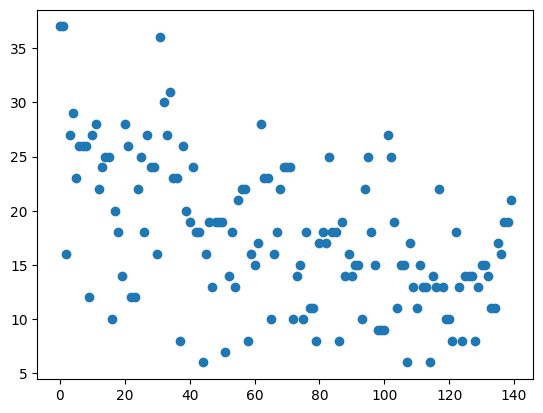

In [ ]:
plt.scatter(df_40.index, df_40.result) # decreasing as time goes

### Problem 41

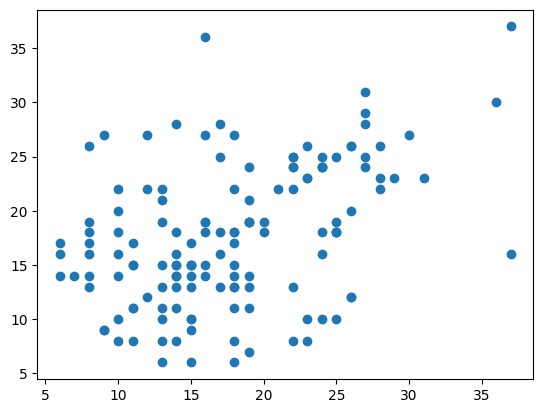

In [ ]:
plt.scatter(df_40.result[:-1], df_40.result[1:]) # no correlation below ~25. positive correlation beyond ~25

### Problem 42

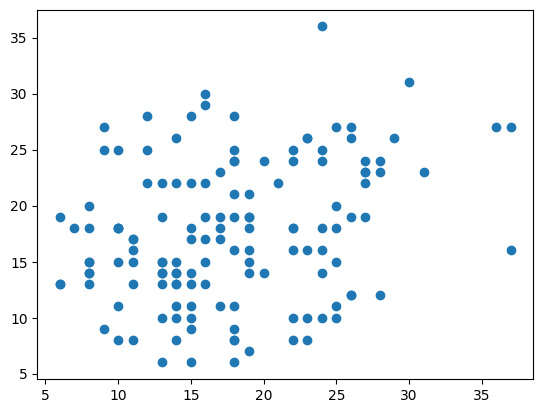

In [229]:
plt.scatter(df_40.result[:-2], df_40.result[2:]) # almost no correlation

### Problem 43

In [253]:
rs_43 = []
y_mean_40 = df_40.result.mean()
for k in range(1,df_40.shape[0]):
    arr1 = (df_40.result[:-k] - y_mean_40).to_numpy()
    arr2 = (df_40.result[k:] - y_mean_40).to_numpy()
    rs_43.append((arr1*arr2).sum() / (arr1**2).sum())
rs_43

[np.float64(0.40816785485522017),
 np.float64(0.258796485076165),
 np.float64(0.25027879320287794),
 np.float64(0.23194690331815787),
 np.float64(0.20917384856635712),
 np.float64(0.2509296749041386),
 np.float64(0.5735208426985194),
 np.float64(0.15929610334146113),
 np.float64(0.11426854268458707),
 np.float64(0.16547168507335053),
 np.float64(0.12450404779669164),
 np.float64(0.09167027572765776),
 np.float64(0.12850236443107796),
 np.float64(0.4390437440345981),
 np.float64(0.06078021735278744),
 np.float64(0.023621387434104385),
 np.float64(0.06697749285446224),
 np.float64(0.05054925215877522),
 np.float64(0.08502585052700401),
 np.float64(0.16540386172486485),
 np.float64(0.4435477277981649),
 np.float64(0.05575106649327783),
 np.float64(0.08985678750263591),
 np.float64(0.13690783353914415),
 np.float64(0.15997933266072079),
 np.float64(0.15024960132608564),
 np.float64(0.12994775732953975),
 np.float64(0.4193642077359946),
 np.float64(0.07264986282187734),
 np.float64(0.174680

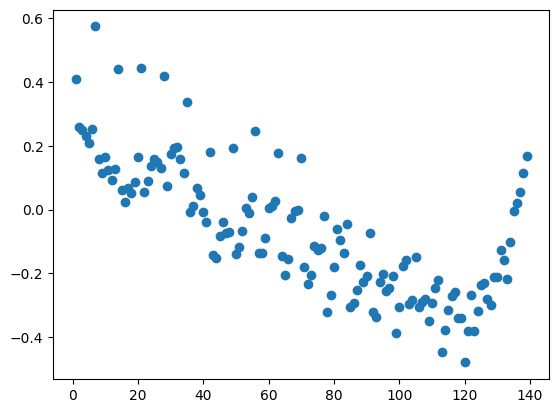

In [254]:
plt.scatter(np.arange(1,df_40.shape[0]), rs_43)

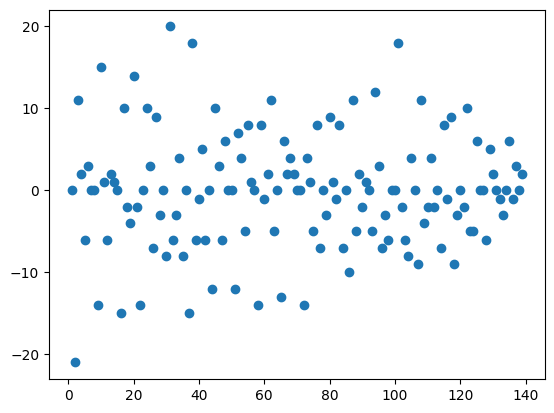

In [259]:
plt.scatter(df_40.index, df_40.result.diff(1)) # 

### repeat Problem 40 to 46

In [262]:
df_45 = df_40.diff().dropna()

In [263]:
df_45

,result
1,0.0
2,-21.0
3,11.0
4,2.0
5,-6.0
...,...
135,6.0
136,-1.0
137,3.0
138,0.0


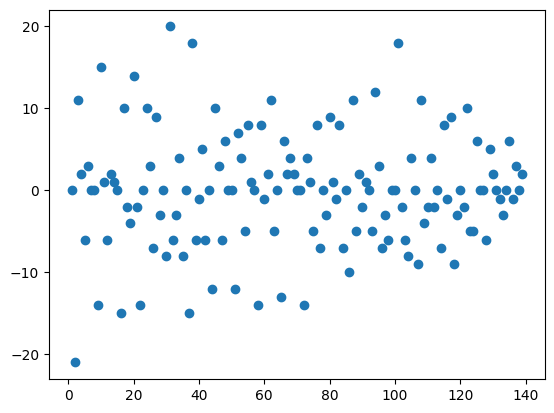

In [266]:
plt.scatter(df_45.index, df_45.result) # not time dependent

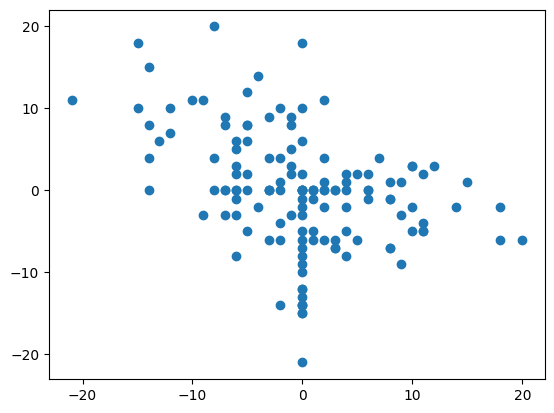

In [268]:
plt.scatter(df_45.result[:-1], df_45.result[1:]) # negative correlation 

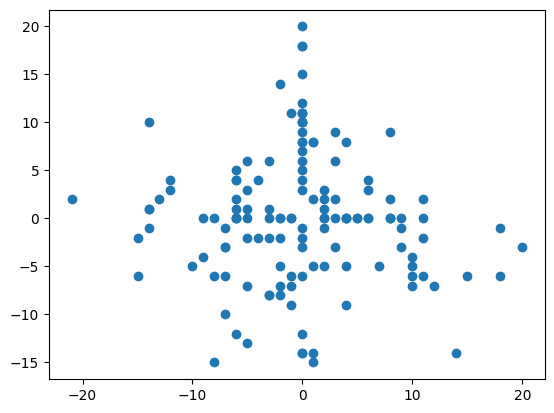

In [ ]:
plt.scatter(df_45.result[:-2], df_45.result[2:]) # no apparent correlation 

In [271]:
rs_45 = []
y_mean_45 = df_45.result.mean()
for k in range(1,df_45.shape[0]):
    arr11 = (df_45.result[:-k] - y_mean_45).to_numpy()
    arr22 = (df_45.result[k:] - y_mean_45).to_numpy()
    rs_45.append((arr11*arr22).sum() / (arr11**2).sum())
rs_45

[np.float64(-0.39434154935008703),
 np.float64(-0.06695107997782185),
 np.float64(-0.020576432391070543),
 np.float64(-0.0023765518480823753),
 np.float64(-0.036704748043090055),
 np.float64(-0.2555776693265351),
 np.float64(0.647144001154088),
 np.float64(-0.32675494172267516),
 np.float64(-0.045390808073970015),
 np.float64(0.03995463830153012),
 np.float64(-0.007231319658559077),
 np.float64(-0.04807602809181453),
 np.float64(-0.2424272430347152),
 np.float64(0.5925818368749016),
 np.float64(-0.2939942899934024),
 np.float64(-0.02919958777316272),
 np.float64(0.020026746498107227),
 np.float64(-0.03255622032472575),
 np.float64(-0.027934320442150152),
 np.float64(-0.20512143227683247),
 np.float64(0.5609030690341776),
 np.float64(-0.32078303501653066),
 np.float64(-0.00623867814299008),
 np.float64(-0.010128325143535859),
 np.float64(0.025642685311637374),
 np.float64(0.023400856326245844),
 np.float64(-0.2858693163231124),
 np.float64(0.537851782849166),
 np.float64(-0.372079447419